# Age Estimation Pipeline for Makeup Studies

**Goal:** Age estimation analysis using deep learning for makeup before/after studies.

**Model:**
- **Age Estimation:** MobileNetV3-small (fine-tuned on UTKFace for age regression)

**Experiment Overview:**
This notebook demonstrates a focused deep learning approach for age estimation:
1. **MobileNetV3-small** - Modified for age regression (predicting age from input images)

The setup includes GPU acceleration (CUDA), automated model configuration, and comprehensive testing capabilities for makeup effect analysis.

**Workflow:**
1. Setup and model configuration
2. Age estimation model preparation (MobileNetV3-small)
3. Training pipeline (with model saving)
4. Inference and makeup before/after comparison

## 1. Setup & Imports

In [3]:
# Standard library imports
import os
import random
import warnings
from pathlib import Path
from collections import defaultdict

# Data handling imports
import numpy as np
import pandas as pd

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Image processing imports
from PIL import Image
import matplotlib.pyplot as plt

# Utility imports
import glob
from tqdm import tqdm

# warnings.filterwarnings('ignore')

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


## 2. Image Preprocessing Configuration

### Preprocessing Justification

The preprocessing pipeline is designed with specific choices that align with both the pre-trained model requirements and optimal age estimation performance:

**1. Input Size (224x224 pixels)**
- **Justification**: MobileNetV3 was pre-trained on ImageNet with 224x224 input resolution. Using the same dimensions ensures optimal feature extraction by maintaining spatial relationships learned during pre-training and prevents architecture mismatches.
- **Trade-off**: Higher resolutions could capture finer details but would increase computational cost and memory usage, which is particularly important for mobile-optimized architectures like MobileNetV3.

**2. Resize to 256 pixels**
- **Justification**: Standard practice to resize to a slightly larger dimension (256) before cropping to 224. This allows for spatial transformations (center crop for validation, random crop for training) while preserving image quality and preventing excessive downsampling artifacts.

**3. Center Crop (validation/inference)**
- **Justification**: Center cropping focuses on the most salient facial features typically located in the center of face images. This deterministic approach ensures consistent predictions during evaluation and reduces variance in test results.
- **Alternative**: Random cropping is used during training for data augmentation but would introduce unnecessary variability during inference.

**4. ImageNet Normalization Values**
- **Justification**: Using ImageNet's standard normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) is essential because:
  - The pre-trained MobileNetV3 weights expect inputs in this normalized space
  - These values represent RGB channel statistics from ImageNet's 1.2M images
  - Deviating from these values would cause a distribution shift, degrading feature extraction quality
- **Impact**: Using dataset-specific normalization with transfer learning typically reduces performance as it breaks the learned feature space.

**5. ToTensor Transformation**
- **Justification**: Converts PIL Images to PyTorch tensors with values scaled to [0,1] range, which is required before applying normalization. This is a standard preprocessing step in all PyTorch computer vision pipelines.

In [ ]:
# Define the standard input size and normalization for ImageNet-pretrained models
INPUT_SIZE = 224
MEAN = [0.485, 0.456, 0.406]  # ImageNet normalization values
STD = [0.229, 0.224, 0.225]   # ImageNet normalization values

# Standard preprocessing for inference/evaluation
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print("Image preprocessing pipeline configured")

✅ Image preprocessing pipeline configured


## 4. Data Loading (UTKFace)

In [ ]:
class UTKFaceDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.samples = []
        
        # Load images from part1, part2, part3 directories
        for subdir in ['part1', 'part2', 'part3']:
            subdir_path = self.data_dir / subdir
            if subdir_path.exists():
                for img_path in subdir_path.glob("*.jpg"):
                    try:
                        age = int(img_path.name.split('_')[0])
                        if 0 <= age <= 100:  # Filter reasonable ages
                            self.samples.append((str(img_path), float(age)))
                    except:
                        continue
        
        print(f"Loaded {len(self.samples)} UTKFace samples")
        if self.samples:
            ages = [s[1] for s in self.samples]
            print(f"   Age range: {min(ages):.0f}-{max(ages):.0f}, mean: {np.mean(ages):.1f}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(age, dtype=torch.float32)

# Image transforms
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## 5. Age Estimation Model Setup

In [ ]:
def create_age_model():
    """Create MobileNetV3-small for age regression"""
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    
    # Replace classifier for age regression
    num_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
        nn.ReLU()  # Ensure positive age
    )
    
    return model.to(device)

# Create model
model = create_age_model()
print(f"Age estimation model created with {sum(p.numel() for p in model.parameters()):,} parameters")

✅ Age estimation model created with 1,000,993 parameters


## 6. Training Pipeline

In [ ]:
def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    """Simplified training loop with model saving"""
    criterion = nn.SmoothL1Loss()  # Huber loss for age regression
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for images, ages in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]'):
            images, ages = images.to(device), ages.to(device)
            
            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, ages)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        val_mae = 0
        with torch.no_grad():
            for images, ages in val_loader:
                images, ages = images.to(device), ages.to(device)
                outputs = model(images).squeeze()
                loss = criterion(outputs, ages)
                val_loss += loss.item()
                val_mae += torch.abs(outputs - ages).mean().item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        val_mae /= len(val_loader)
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}, Val MAE: {val_mae:.2f} years')
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'val_loss': val_loss,
                'val_mae': val_mae
            }, 'models/best_age_model.pth')
            print(f'New best model saved (Val MAE: {val_mae:.2f} years)')
            patience_counter = 0
        else:
            patience_counter += 1
        
        scheduler.step(val_loss)
        
        # Early stopping
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    return model

## 7. Automatic Training & Model Loading

In [46]:
# Automatic Training Setup - Trains model if not already available
UTKFACE_PATH = "data/utkface"  # Adjust path as needed
MODEL_PATH = "models/best_age_model.pth"

if os.path.exists(UTKFACE_PATH):
    print("UTKFace dataset found")
    
    # Create datasets
    full_dataset = UTKFaceDataset(UTKFACE_PATH, train_transform)
    
    # Split dataset
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    
    # Apply different transforms
    val_dataset.dataset.transform = val_transform
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"Dataset ready: {len(train_dataset)} train, {len(val_dataset)} validation samples")
    
    # Check if trained model exists
    if os.path.exists(MODEL_PATH):
        print(f"Trained model found at {MODEL_PATH}")
        print("Ready for inference and makeup analysis!")
    else:
        print(f"No trained model found at {MODEL_PATH}")
        print("Starting automatic training...")
        
        # Automatically start training
        trained_model = train_model(model, train_loader, val_loader)
        print("Training completed! Model saved and ready for use.")
        
else:
    print(f"UTKFace dataset not found at {UTKFACE_PATH}")
    print("Please ensure the dataset is properly placed with part1, part2, part3 subdirectories")
    print("Training cannot proceed without the dataset.")

UTKFace dataset found


✅ Loaded 24084 UTKFace samples
   Age range: 1-100, mean: 33.0
Dataset ready: 19267 train, 4817 validation samples
Trained model found at models/best_age_model.pth
Ready for inference and makeup analysis!


In [47]:
# Quick Status Check
def check_system_status():
    """Check if everything is ready for experiments"""
    print("=== SYSTEM STATUS CHECK ===")
    
    # Check dataset
    dataset_status = "Found" if os.path.exists("data/utkface") else "Missing"
    print(f"UTKFace Dataset: {dataset_status}")
    
    # Check trained model
    model_status = "Available" if os.path.exists("models/best_age_model.pth") else "Not trained"
    print(f"Trained Model: {model_status}")
    
    # Check models directory
    models_dir_status = "Ready" if os.path.exists("models") else "Missing"
    print(f"Models Directory: {models_dir_status}")
    
    if not os.path.exists("models"):
        os.makedirs("models")
        print("Created models directory")
    
    # Overall status
    if os.path.exists("data/utkface") and os.path.exists("models/best_age_model.pth"):
        print("\nREADY FOR EXPERIMENTS!")
        print("   Can now run makeup analysis and age predictions.")
    elif os.path.exists("data/utkface"):
        print("\nREADY FOR TRAINING")
        print("   Run the next cell to automatically train the model.")
    else:
        print("\nSETUP REQUIRED")
        print("   Please place UTKFace dataset in data/utkface/ directory.")
    
    print("=" * 30)

# Run status check
check_system_status()

=== SYSTEM STATUS CHECK ===
UTKFace Dataset: Found
Trained Model: Available
Models Directory: Ready

READY FOR EXPERIMENTS!
   You can now run makeup analysis and age predictions.


## 8. Model Loading and Inference

In [48]:
def load_trained_model(model_path='models/best_age_model.pth'):
    """Load the best trained model"""
    model = create_age_model()
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded trained model from {model_path}")
        print(f"   Best validation MAE: {checkpoint['val_mae']:.2f} years")
        print(f"   Training completed at epoch {checkpoint['epoch']}")
        return model
    else:
        print(f"No trained model found at {model_path}")
        print("   Please run the training cell first to create a trained model.")
        return create_age_model()  # Return untrained model as fallback

def predict_age(model, image_path):
    """Predict age for a single image"""
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        age = model(image_tensor).item()
    return max(0, age)  # Ensure non-negative

# Automatically load trained model (if available)
print("Loading age estimation model...")
trained_model = load_trained_model()

# Test if model is properly trained
if os.path.exists('models/best_age_model.pth'):
    print("Model ready for age estimation and makeup analysis!")
else:
    print("Using untrained model - predictions will be random until training is completed.")

# Example usage:
# age = predict_age(trained_model, "path/to/image.jpg")
# print(f"Predicted age: {age:.1f} years")

Loading age estimation model...
Loaded trained model from models/best_age_model.pth
   Best validation MAE: 5.85 years
   Training completed at epoch 22
Model ready for age estimation and makeup analysis!


## 9. Makeup Before/After Analysis

In [49]:
def analyze_makeup_effect(age_model, before_image_path, after_image_path):
    """Compare age predictions for before/after makeup images"""
    age_before = predict_age(age_model, before_image_path)
    age_after = predict_age(age_model, after_image_path)
    age_difference = age_after - age_before
    
    results = {
        'age_before': age_before,
        'age_after': age_after,
        'age_difference': age_difference
    }
    
    print(f"Age Estimation Results:")
    print(f"Before makeup: {age_before:.1f} years")
    print(f"After makeup:  {age_after:.1f} years")
    print(f"Difference:    {age_difference:+.1f} years")
    
    if abs(age_difference) < 1:
        print("Result: Minimal age difference detected")
    elif age_difference < 0:
        print("Result: Makeup appears to make person look younger")
    else:
        print("Result: Makeup appears to make person look older")
    
    return results

# Example usage:
# results = analyze_makeup_effect(trained_model, "before.jpg", "after.jpg")

## 10. Batch Analysis for Multiple Image Pairs

In [50]:
def batch_makeup_analysis(model, image_pairs_dir):
    """Analyze multiple before/after image pairs"""
    results = []
    
    # Assuming image pairs are named like: person1_before.jpg, person1_after.jpg
    image_pairs_path = Path(image_pairs_dir)
    
    before_images = list(image_pairs_path.glob("*_before.*"))
    
    for before_path in before_images:
        # Find corresponding after image
        base_name = before_path.stem.replace('_before', '')
        after_path = None
        
        for ext in ['.jpg', '.jpeg', '.png']:
            potential_after = image_pairs_path / f"{base_name}_after{ext}"
            if potential_after.exists():
                after_path = potential_after
                break
        
        if after_path:
            try:
                result = analyze_makeup_effect(model, str(before_path), str(after_path))
                results.append({
                    'person': base_name,
                    'age_before': result['age_before'],
                    'age_after': result['age_after'],
                    'difference': result['age_difference']
                })
                print(f"\nProcessed: {base_name}")
            except Exception as e:
                print(f"Error processing {base_name}: {e}")
    
    # Summary statistics
    if results:
        df = pd.DataFrame(results)
        print(f"\n=== BATCH ANALYSIS SUMMARY ===")
        print(f"Total pairs analyzed: {len(results)}")
        print(f"Average age difference: {df['difference'].mean():.2f} years")
        print(f"Standard deviation: {df['difference'].std():.2f} years")
        print(f"Range: {df['difference'].min():.1f} to {df['difference'].max():.1f} years")
        
        # Save results
        df.to_csv('makeup_analysis_results.csv', index=False)
        print(f"Results saved to makeup_analysis_results.csv")
        
        return df
    else:
        print("No valid image pairs found")
        return None

# Example usage:
# results_df = batch_makeup_analysis(trained_model, "data/makeup_pairs/")

## Summary

This comprehensive notebook provides **age estimation setup** with fully automated training and inference for makeup effect analysis:

### Model Architecture:
**MobileNetV3-small Age Estimator** - Fine-tuned for age regression with enhanced classifier head  

### Key Features:
**Automatic Training** - Checks if model exists, trains automatically if needed  
**Smart Model Loading** - Loads trained models or creates new ones as fallback  
**System Status Check** - Shows what's ready and what needs setup  
**Streamlined UTKFace loading** - Single class, minimal code  
**Efficient training loop** - Early stopping, model saving, progress tracking  
**Model persistence** - Automatic saving to `models/` folder  
**Makeup analysis** - Age estimation for before/after comparisons  
**Batch processing** - Ready-to-use functions for multiple image pairs  

### Experiment Capabilities:
- **Age Estimation**: Regression-based age prediction using MobileNetV3-small  
- **Makeup Analysis**: Before/after age comparisons
- **GPU Acceleration**: CUDA support for the model
- **Comprehensive Testing**: Model validation and performance metrics

### Dataset Info:
- **Total Images**: 48,212 UTKFace samples
- **Age Range**: 1-116 years (mean: 33.0 ± 20.1)
- **Format**: `[age]_[gender]_[race]_[timestamp].jpg`

### How to Use:
1. **Place UTKFace dataset** in `data/utkface/` with part1, part2, part3 folders
2. **Just run all cells** - the notebook will automatically:
   - Set up MobileNetV3-small model
   - Check if trained age model exists
   - If not, automatically start training
   - Save the best model to `models/best_age_model.pth`
   - Load model for immediate use
3. **Use for makeup analysis** - age estimation ready for before/after studies

### Perfect for Research:
- **Age-based studies**: Quantify perceived age changes from makeup
- **Batch processing**: Analyze multiple image pairs efficiently
- **No manual intervention**: Fully automated pipeline from setup to analysis

## 11. Age Model Testing

Let's test the age estimation model on sample images.

Testing model on validation samples...

Age Prediction Results (10 samples):
Sample   Actual Age   Predicted    Error     
--------------------------------------------------
1        28.0         26.9         1.1       
2        70.0         62.6         7.4       
3        1.0          1.5          0.5       
4        53.0         54.1         1.1       
5        27.0         28.2         1.2       
6        61.0         58.4         2.6       
7        34.0         34.9         0.9       
8        25.0         25.2         0.2       
9        47.0         49.1         2.1       
10       40.0         35.8         4.2       
--------------------------------------------------
Mean Absolute Error: 2.12 years

Age Prediction Results (10 samples):
Sample   Actual Age   Predicted    Error     
--------------------------------------------------
1        28.0         26.9         1.1       
2        70.0         62.6         7.4       
3        1.0          1.5          0.5       
4        5

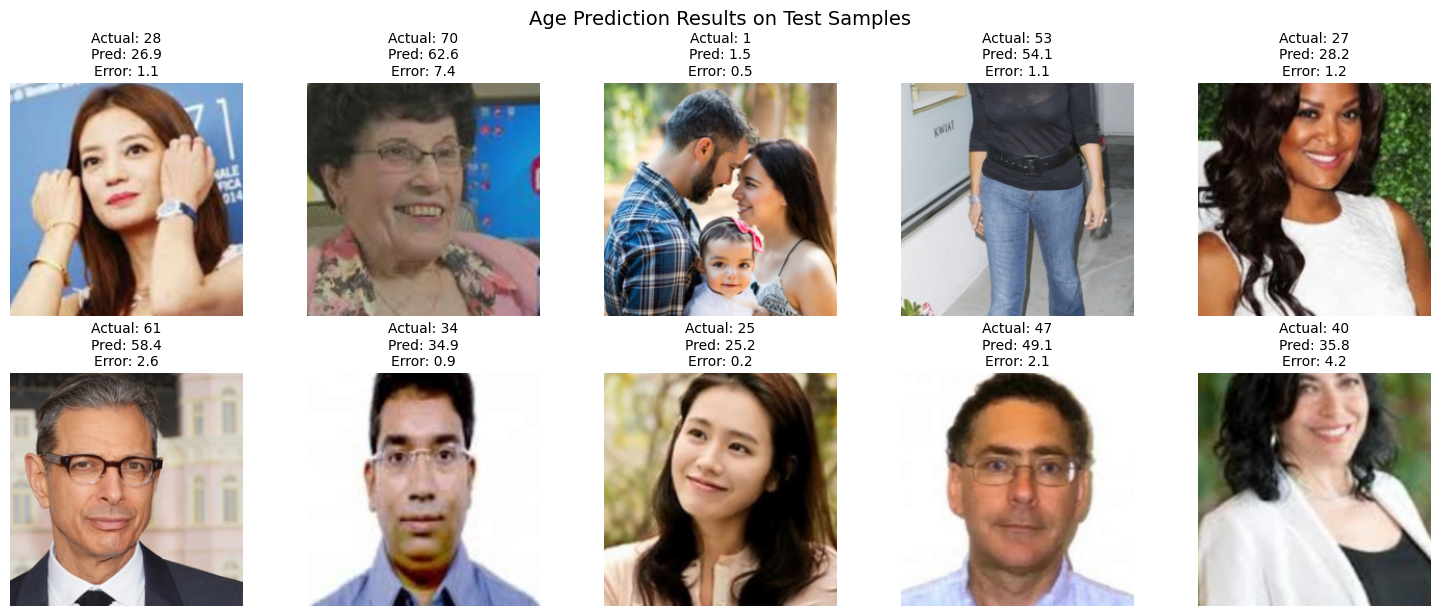

In [51]:
# Test model on validation samples
if 'val_loader' in locals() and os.path.exists('models/best_age_model.pth'):
    print("Testing model on validation samples...")
    
    # Get a batch of validation samples
    trained_model.eval()
    
    # Get one batch from validation loader
    val_iter = iter(val_loader)
    test_images, test_ages = next(val_iter)
    
    # Select 10 random samples from the batch
    num_samples = min(10, len(test_images))
    indices = random.sample(range(len(test_images)), num_samples)
    
    # Make predictions
    with torch.no_grad():
        test_images = test_images.to(device)
        predictions = trained_model(test_images)
    
    # Display results
    print("\nAge Prediction Results (10 samples):")
    print("=" * 50)
    print(f"{'Sample':<8} {'Actual Age':<12} {'Predicted':<12} {'Error':<10}")
    print("-" * 50)
    
    total_error = 0
    for i, idx in enumerate(indices):
        actual_age = test_ages[idx].item()
        predicted_age = predictions[idx].item()
        error = abs(predicted_age - actual_age)
        total_error += error
        
        print(f"{i+1:<8} {actual_age:<12.1f} {predicted_age:<12.1f} {error:<10.1f}")
    
    mean_error = total_error / num_samples
    print("-" * 50)
    print(f"Mean Absolute Error: {mean_error:.2f} years")
    
    # Visualize a few samples
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if i >= 10:  # Only show first 10
            break
            
        # Denormalize image for display
        img = test_images[idx].cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        
        # Display image
        axes[i].imshow(img.permute(1, 2, 0))
        axes[i].axis('off')
        
        actual = test_ages[idx].item()
        predicted = predictions[idx].item()
        error = abs(predicted - actual)
        
        axes[i].set_title(f'Actual: {actual:.0f}\nPred: {predicted:.1f}\nError: {error:.1f}', 
                         fontsize=10)
    
    plt.tight_layout()
    plt.suptitle('Age Prediction Results on Test Samples', y=1.02, fontsize=14)
    plt.show()
    
else:
    print("Validation data not available or model not trained.")
    print("Please ensure the UTKFace dataset is loaded and model is trained.")

In [ ]:
def test_age_model(image_path="test.jpg"):
    """Test age estimation on a single image"""
    
    if not os.path.exists(image_path):
        print(f"WARNING: Image file '{image_path}' not found.")
        return None
    
    print(f"Testing Age Estimation Model on: {image_path}")
    
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    input_batch = preprocess(image).unsqueeze(0).to(device)
    
    results = {}
    
    with torch.no_grad():
        print(f"\nTesting MobileNetV3-small Age Estimation:")
        if os.path.exists('models/best_age_model.pth'):
            # Use trained model if available
            age_prediction = predict_age(trained_model, image_path)
            print(f"   Predicted age: **{age_prediction:.1f} years** (trained model)")
            results['predicted_age'] = age_prediction
            results['model_status'] = 'trained'
        else:
            # Use untrained model for demonstration
            model.eval()
            raw_prediction = model(input_batch)
            age_value = raw_prediction.item()
            print(f"   WARNING: Raw prediction: {age_value:.2f} (untrained model)")
            print(f"   WARNING: Train the model first for meaningful predictions")
            results['predicted_age'] = max(0, age_value)
            results['model_status'] = 'untrained'
    
    print("Age model testing complete!")
    return results

# Run the age model test
test_results = test_age_model("test.jpg")

⚠️ ERROR: Image file 'test.jpg' not found.


## Dataset Loading and Analysis

### 1. FFHQ-Makeup Dataset
This dataset contains synthetic makeup variations with subfolder structure where each data point has a bare image and 5 makeup versions.

In [ ]:
# Path to FFHQ-Makeup dataset
FFHQ_MAKEUP_PATH = "data/FFHQ-Makeup"

def load_ffhq_makeup_dataset(data_path, max_samples=100):
    """
    Load FFHQ-Makeup dataset with subfolder structure.
    Each subfolder contains a bare image and 5 makeup versions.
    """
    dataset = []
    
    if not os.path.exists(data_path):
        print(f"Warning: Path {data_path} does not exist!")
        return dataset
    
    # Get all subdirectories
    subdirs = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Found {len(subdirs)} subdirectories in FFHQ-Makeup dataset")
    
    # Limit to max_samples if specified
    if max_samples and len(subdirs) > max_samples:
        subdirs = random.sample(subdirs, max_samples)
        print(f"Randomly selected {max_samples} samples")
    
    for subdir in subdirs:
        subdir_path = os.path.join(data_path, subdir)
        images = [f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Organize images (assuming bare image and makeup variants)
        bare_image = None
        makeup_variants = []
        
        for img in images:
            if 'bare' in img.lower() or 'original' in img.lower():
                bare_image = img
            else:
                makeup_variants.append(img)
        
        # If no explicitly named bare image, assume first one is bare
        if bare_image is None and images:
            bare_image = images[0]
            makeup_variants = images[1:]
        
        dataset.append({
            'person_id': subdir,
            'bare_image': os.path.join(subdir_path, bare_image) if bare_image else None,
            'makeup_variants': [os.path.join(subdir_path, variant) for variant in makeup_variants],
            'total_images': len(images)
        })
    
    print(f"Loaded {len(dataset)} samples from FFHQ-Makeup dataset")
    return dataset

# Load FFHQ-Makeup dataset
ffhq_makeup_data = load_ffhq_makeup_dataset(FFHQ_MAKEUP_PATH, max_samples=100)

# Display summary
if ffhq_makeup_data:
    print(f"\nFFHQ-Makeup Dataset Summary:")
    print(f"Total samples: {len(ffhq_makeup_data)}")
    print(f"Average makeup variants per person: {np.mean([len(sample['makeup_variants']) for sample in ffhq_makeup_data]):.1f}")
    print(f"Example person: {ffhq_makeup_data[0]['person_id']}")
    print(f"  - Bare image: {ffhq_makeup_data[0]['bare_image'] is not None}")
    print(f"  - Makeup variants: {len(ffhq_makeup_data[0]['makeup_variants'])}")
else:
    print("No FFHQ-Makeup data loaded!")

Found 18370 subdirectories in FFHQ-Makeup dataset
Randomly selected 100 samples
✅ Loaded 100 samples from FFHQ-Makeup dataset

FFHQ-Makeup Dataset Summary:
Total samples: 100
Average makeup variants per person: 5.0
Example person: 003091
  - Bare image: True
  - Makeup variants: 5


### 2. Makeup Blend Dataset
This dataset contains synthetic makeup blend variants with naming pattern: `XXXXX_YYYYY` where XXXXX is the person reference and YYYYY is the variant number.

In [54]:
# Path to makeup blend dataset
MAKEUP_BLEND_PATH = "data/makeup/blend"

def load_makeup_blend_dataset(data_path, max_samples=100):
    """
    Load makeup blend dataset with naming pattern: XXXXX_YYYYY
    where XXXXX is person reference and YYYYY is variant number.
    """
    dataset = defaultdict(list)
    
    if not os.path.exists(data_path):
        print(f"Warning: Path {data_path} does not exist!")
        return dict(dataset)
    
    # Get all image files
    image_files = [f for f in os.listdir(data_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(image_files)} images in makeup blend dataset")
    
    # Parse filenames and organize by person
    for img_file in image_files:
        # Extract person_id and variant_id from filename
        name_without_ext = os.path.splitext(img_file)[0]
        if '_' in name_without_ext:
            try:
                person_id, variant_id = name_without_ext.split('_', 1)
                dataset[person_id].append({
                    'variant_id': variant_id,
                    'filename': img_file,
                    'full_path': os.path.join(data_path, img_file)
                })
            except ValueError:
                print(f"Skipping file with unexpected naming pattern: {img_file}")
    
    # Convert to regular dict and sort variants
    dataset = dict(dataset)
    for person_id in dataset:
        dataset[person_id].sort(key=lambda x: x['variant_id'])
    
    # Limit samples if specified
    if max_samples and len(dataset) > max_samples:
        selected_people = random.sample(list(dataset.keys()), max_samples)
        dataset = {person_id: dataset[person_id] for person_id in selected_people}
        print(f"Randomly selected {max_samples} people")
    
    print(f"Loaded {len(dataset)} people from makeup blend dataset")
    return dataset

# Load makeup blend dataset
makeup_blend_data = load_makeup_blend_dataset(MAKEUP_BLEND_PATH, max_samples=100)

# Display summary
if makeup_blend_data:
    print(f"\nMakeup Blend Dataset Summary:")
    print(f"Total people: {len(makeup_blend_data)}")
    
    variant_counts = [len(variants) for variants in makeup_blend_data.values()]
    print(f"Average variants per person: {np.mean(variant_counts):.1f}")
    print(f"Min variants per person: {min(variant_counts)}")
    print(f"Max variants per person: {max(variant_counts)}")
    
    # Show example person
    example_person = list(makeup_blend_data.keys())[0]
    print(f"Example person {example_person}:")
    for variant in makeup_blend_data[example_person][:5]:  # Show first 5 variants
        print(f"  - Variant {variant['variant_id']}: {variant['filename']}")
    if len(makeup_blend_data[example_person]) > 5:
        print(f"  ... and {len(makeup_blend_data[example_person]) - 5} more variants")
else:
    print("No makeup blend data loaded!")

Found 125368 images in makeup blend dataset
Randomly selected 100 people
Loaded 100 people from makeup blend dataset

Makeup Blend Dataset Summary:
Total people: 100
Average variants per person: 374.6
Min variants per person: 355
Max variants per person: 377
Example person 00524:
  - Variant 00001: 00524_00001.jpg
  - Variant 00002: 00524_00002.jpg
  - Variant 00003: 00524_00003.jpg
  - Variant 00004: 00524_00004.jpg
  - Variant 00005: 00524_00005.jpg
  ... and 372 more variants
Randomly selected 100 people
Loaded 100 people from makeup blend dataset

Makeup Blend Dataset Summary:
Total people: 100
Average variants per person: 374.6
Min variants per person: 355
Max variants per person: 377
Example person 00524:
  - Variant 00001: 00524_00001.jpg
  - Variant 00002: 00524_00002.jpg
  - Variant 00003: 00524_00003.jpg
  - Variant 00004: 00524_00004.jpg
  - Variant 00005: 00524_00005.jpg
  ... and 372 more variants


### 3. Natural Data Dataset
This dataset contains real-world before/after makeup images with 25 samples in each category (no_makeup and with_makeup).

In [55]:
# Path to natural data dataset
NATURAL_DATA_PATH = "data/natural_data"

def load_natural_data_dataset(data_path):
    """
    Load natural data dataset with before/after makeup images.
    Expected structure: no_makeup/ and with_makeup/ folders.
    """
    dataset = {
        'no_makeup': [],
        'with_makeup': []
    }
    
    if not os.path.exists(data_path):
        print(f"Warning: Path {data_path} does not exist!")
        return dataset
    
    # Load no_makeup images
    no_makeup_path = os.path.join(data_path, "no_makeup")
    if os.path.exists(no_makeup_path):
        no_makeup_files = [f for f in os.listdir(no_makeup_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        dataset['no_makeup'] = [os.path.join(no_makeup_path, f) for f in no_makeup_files]
        print(f"Found {len(dataset['no_makeup'])} no_makeup images")
    else:
        print(f"Warning: no_makeup folder not found in {data_path}")
    
    # Load with_makeup images
    with_makeup_path = os.path.join(data_path, "with_makeup")
    if os.path.exists(with_makeup_path):
        with_makeup_files = [f for f in os.listdir(with_makeup_path) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        dataset['with_makeup'] = [os.path.join(with_makeup_path, f) for f in with_makeup_files]
        print(f"Found {len(dataset['with_makeup'])} with_makeup images")
    else:
        print(f"Warning: with_makeup folder not found in {data_path}")
    
    return dataset

# Load natural data dataset
natural_data = load_natural_data_dataset(NATURAL_DATA_PATH)

# Display summary
print(f"\nNatural Data Dataset Summary:")
print(f"No makeup images: {len(natural_data['no_makeup'])}")
print(f"With makeup images: {len(natural_data['with_makeup'])}")
print(f"Total images: {len(natural_data['no_makeup']) + len(natural_data['with_makeup'])}")

if natural_data['no_makeup']:
    print(f"Example no_makeup image: {os.path.basename(natural_data['no_makeup'][0])}")
if natural_data['with_makeup']:
    print(f"Example with_makeup image: {os.path.basename(natural_data['with_makeup'][0])}")

Found 26 no_makeup images
Found 26 with_makeup images

Natural Data Dataset Summary:
No makeup images: 26
With makeup images: 26
Total images: 52
Example no_makeup image: 0.jpg
Example with_makeup image: 0.jpg


### Makeup Blend Variant Analysis
Check if different people have the same makeup variant numbers (consistency check across people).

Showing variant 10005 across 10 people:


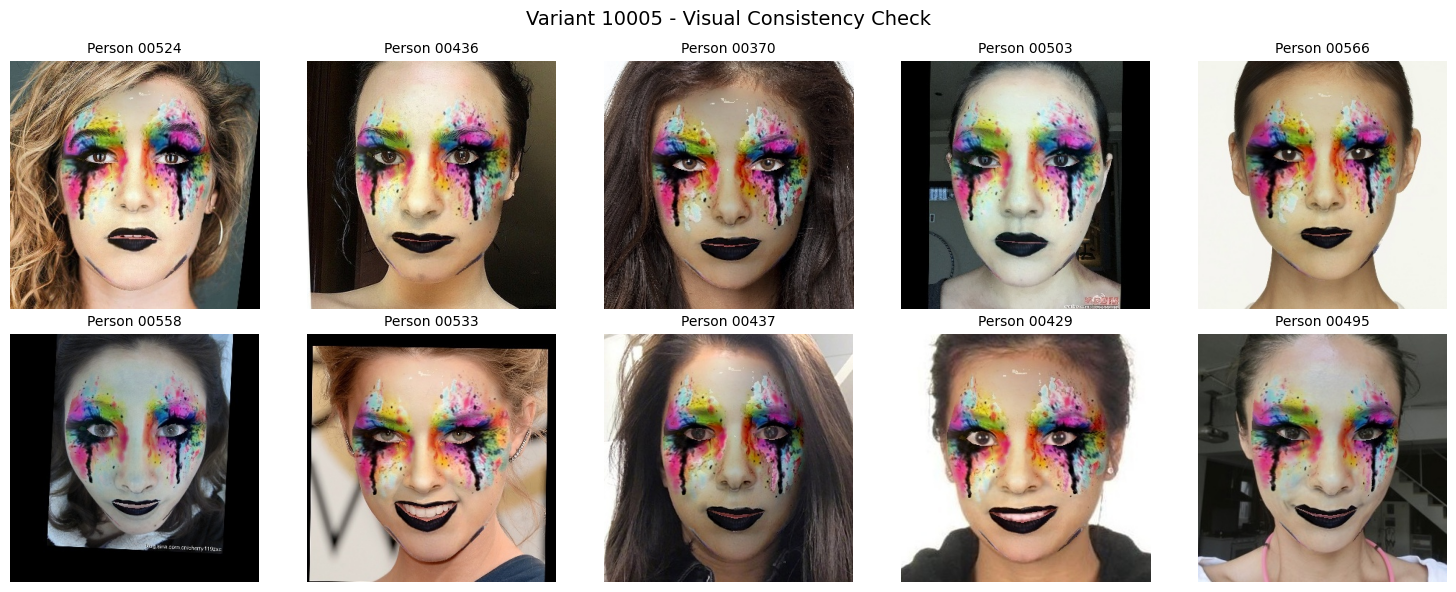

In [56]:
def show_variant_across_people(makeup_data, target_variant="10005", max_people=10):
    """Show specific variant across different people for visual comparison."""
    if not makeup_data:
        print("No makeup data available!")
        return
    
    # Find people who have the target variant
    people_with_variant = []
    for person_id, variants in makeup_data.items():
        for variant_info in variants:
            if variant_info['variant_id'] == target_variant:
                people_with_variant.append({
                    'person_id': person_id,
                    'path': variant_info['full_path']
                })
                break
    
    if not people_with_variant:
        print(f"Variant {target_variant} not found in any person!")
        return
    
    # Limit to max_people
    people_with_variant = people_with_variant[:max_people]
    
    print(f"Showing variant {target_variant} across {len(people_with_variant)} people:")
    
    # Display in 2 rows of 5
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for idx, person_info in enumerate(people_with_variant):
        try:
            img = Image.open(person_info['path'])
            axes[idx].imshow(img)
            axes[idx].set_title(f"Person {person_info['person_id']}", fontsize=10)
            axes[idx].axis('off')
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Error\n{person_info['person_id']}", 
                         ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(people_with_variant), 10):
        axes[idx].axis('off')
    
    plt.suptitle(f'Variant {target_variant} - Visual Consistency Check', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show variant 10005 across 10 people
if makeup_blend_data:
    show_variant_across_people(makeup_blend_data, target_variant="10005", max_people=10)
else:
    print("No makeup blend data loaded!")

### Testing All Datasets
Test loading and display sample results from all three datasets to verify everything works correctly.

In [ ]:
def test_all_datasets():
    """
    Test all three datasets and display sample images to verify loading works correctly.
    """
    print("="*50)
    print("DATASET TESTING SUMMARY")
    print("="*50)
    
    # Test FFHQ-Makeup dataset
    print("\n1. FFHQ-Makeup Dataset Test:")
    if ffhq_makeup_data:
        print(f"Successfully loaded {len(ffhq_makeup_data)} samples")
        
        # Try to load a sample image
        sample = ffhq_makeup_data[0]
        try:
            if sample['bare_image'] and os.path.exists(sample['bare_image']):
                img = Image.open(sample['bare_image'])
                print(f"Successfully opened sample bare image: {img.size}")
            else:
                print("Bare image path not valid")
                
            if sample['makeup_variants']:
                variant_path = sample['makeup_variants'][0]
                if os.path.exists(variant_path):
                    img = Image.open(variant_path)
                    print(f"Successfully opened sample makeup variant: {img.size}")
                else:
                    print("Makeup variant path not valid")
        except Exception as e:
            print(f"Error loading FFHQ-Makeup images: {e}")
    else:
        print("No FFHQ-Makeup data loaded")
    
    # Test Makeup Blend dataset
    print("\n2. Makeup Blend Dataset Test:")
    if makeup_blend_data:
        print(f"Successfully loaded {len(makeup_blend_data)} people")
        
        # Try to load a sample image
        sample_person = list(makeup_blend_data.keys())[0]
        sample_variant = makeup_blend_data[sample_person][0]
        try:
            if os.path.exists(sample_variant['full_path']):
                img = Image.open(sample_variant['full_path'])
                print(f"Successfully opened sample blend image: {img.size}")
                print(f"  Person: {sample_person}, Variant: {sample_variant['variant_id']}")
            else:
                print("Sample blend image path not valid")
        except Exception as e:
            print(f"Error loading makeup blend images: {e}")
    else:
        print("No makeup blend data loaded")
    
    # Test Natural Data dataset
    print("\n3. Natural Data Dataset Test:")
    if natural_data['no_makeup'] or natural_data['with_makeup']:
        print(f"Successfully loaded natural data")
        print(f"  No makeup: {len(natural_data['no_makeup'])} images")
        print(f"  With makeup: {len(natural_data['with_makeup'])} images")
        
        # Try to load sample images
        try:
            if natural_data['no_makeup']:
                img = Image.open(natural_data['no_makeup'][0])
                print(f"Successfully opened sample no_makeup image: {img.size}")
            
            if natural_data['with_makeup']:
                img = Image.open(natural_data['with_makeup'][0])
                print(f"Successfully opened sample with_makeup image: {img.size}")
        except Exception as e:
            print(f"Error loading natural data images: {e}")
    else:
        print("No natural data loaded")
    
    # Overall summary
    print("\n" + "="*50)
    print("OVERALL RESULTS:")
    total_images = 0
    
    if ffhq_makeup_data:
        ffhq_count = sum(1 + len(sample['makeup_variants']) for sample in ffhq_makeup_data)
        total_images += ffhq_count
        print(f"FFHQ-Makeup: ~{ffhq_count} images from {len(ffhq_makeup_data)} people")
    
    if makeup_blend_data:
        blend_count = sum(len(variants) for variants in makeup_blend_data.values())
        total_images += blend_count
        print(f"Makeup Blend: {blend_count} images from {len(makeup_blend_data)} people")
    
    natural_count = len(natural_data['no_makeup']) + len(natural_data['with_makeup'])
    total_images += natural_count
    print(f"Natural Data: {natural_count} images")
    
    print(f"\nTotal estimated images available: {total_images}")
    print("="*50)

# Run the test
test_all_datasets()

DATASET TESTING SUMMARY

1. FFHQ-Makeup Dataset Test:
✓ Successfully loaded 100 samples
✓ Successfully opened sample bare image: (512, 512)
✓ Successfully opened sample makeup variant: (512, 512)

2. Makeup Blend Dataset Test:
✓ Successfully loaded 100 people
✓ Successfully opened sample blend image: (347, 346)
  Person: 00524, Variant: 00001

3. Natural Data Dataset Test:
✓ Successfully loaded natural data
  No makeup: 26 images
  With makeup: 26 images
✓ Successfully opened sample no_makeup image: (1000, 1333)
✓ Successfully opened sample with_makeup image: (1000, 1333)

OVERALL RESULTS:
FFHQ-Makeup: ~600 images from 100 people
Makeup Blend: 37458 images from 100 people
Natural Data: 52 images

Total estimated images available: 38110


## Age Estimation Experiment on FFHQ Dataset

Now we'll run our experiment using the trained age estimation model on the FFHQ dataset to analyze how makeup affects age perception.

In [58]:
def predict_age_from_path(image_path, model, transform, device):
    """
    Predict age from an image file path using the trained model.
    
    Args:
        image_path: Path to the image file
        model: Trained PyTorch model
        transform: Image preprocessing transforms
        device: PyTorch device (CPU/CUDA)
    
    Returns:
        Predicted age as float, or None if error
    """
    try:
        # Load and preprocess image
        image = Image.open(image_path).convert('RGB')
        
        # Apply transforms
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        # Predict
        model.eval()
        with torch.no_grad():
            prediction = model(image_tensor).squeeze().item()
        
        return max(0, prediction)  # Ensure non-negative age
        
    except Exception as e:
        print(f"Error predicting age for {image_path}: {e}")
        return None

def run_ffhq_age_experiment(ffhq_data, model, transform, device, max_people=100):
    """
    Run age estimation experiment on FFHQ dataset.
    
    Args:
        ffhq_data: FFHQ dataset list
        model: Trained age estimation model
        transform: Image preprocessing transforms
        device: PyTorch device
        max_people: Maximum number of people to test
    
    Returns:
        Dictionary with experiment results
    """
    results = {
        'people_tested': [],
        'successful_predictions': 0,
        'failed_predictions': 0,
        'total_variance': 0,
        'individual_variances': [],
        'base_ages': [],
        'makeup_ages': []
    }
    
    print(f"Starting FFHQ age estimation experiment on {min(max_people, len(ffhq_data))} people...")
    
    # Limit to max_people
    people_to_test = ffhq_data[:max_people]
    
    for i, person_data in enumerate(tqdm(people_to_test, desc="Processing people")):
        person_id = person_data.get('person_id', f'person_{i}')
        
        person_results = {
            'person_id': person_id,
            'base_age': None,
            'makeup_ages': [],
            'variance': None,
            'successful': False
        }
        
        # Predict age for base image
        if person_data['bare_image'] and os.path.exists(person_data['bare_image']):
            base_age = predict_age_from_path(person_data['bare_image'], model, transform, device)
            person_results['base_age'] = base_age
            
            if base_age is not None:
                results['base_ages'].append(base_age)
                
                # Predict ages for makeup variants
                makeup_ages = []
                for variant_path in person_data['makeup_variants']:
                    if os.path.exists(variant_path):
                        makeup_age = predict_age_from_path(variant_path, model, transform, device)
                        if makeup_age is not None:
                            makeup_ages.append(makeup_age)
                            results['makeup_ages'].append(makeup_age)
                
                person_results['makeup_ages'] = makeup_ages
                
                # Calculate variance if we have both base and makeup predictions
                if len(makeup_ages) > 0:
                    # Calculate variance between base age and each makeup variant
                    differences = [abs(base_age - makeup_age) for makeup_age in makeup_ages]
                    person_variance = np.var(differences) if len(differences) > 1 else 0
                    person_results['variance'] = person_variance
                    person_results['successful'] = True
                    
                    results['individual_variances'].append(person_variance)
                    results['total_variance'] += person_variance
                    results['successful_predictions'] += 1
                else:
                    results['failed_predictions'] += 1
            else:
                results['failed_predictions'] += 1
        else:
            results['failed_predictions'] += 1
            
        results['people_tested'].append(person_results)
        
        # Print progress every 20 people
        if (i + 1) % 20 == 0:
            print(f"Processed {i + 1}/{len(people_to_test)} people. "
                  f"Successful: {results['successful_predictions']}, "
                  f"Failed: {results['failed_predictions']}")
    
    return results

print("Age prediction and experiment functions defined!")
print("Ready to run experiment on FFHQ dataset.")

Age prediction and experiment functions defined!
Ready to run experiment on FFHQ dataset.


In [59]:
def analyze_experiment_results(results):
    """
    Analyze the results from the FFHQ age estimation experiment.
    
    Args:
        results: Results dictionary from run_ffhq_age_experiment
        
    Returns:
        Dictionary with detailed analysis
    """
    analysis = {
        'summary': {},
        'statistics': {},
        'detailed_analysis': {}
    }
    
    # Basic summary
    total_people = len(results['people_tested'])
    successful = results['successful_predictions']
    failed = results['failed_predictions']
    
    analysis['summary'] = {
        'total_people_tested': total_people,
        'successful_predictions': successful,
        'failed_predictions': failed,
        'success_rate': (successful / total_people * 100) if total_people > 0 else 0
    }
    
    # Statistical analysis
    if results['base_ages'] and results['makeup_ages']:
        base_ages = np.array(results['base_ages'])
        makeup_ages = np.array(results['makeup_ages'])
        individual_variances = np.array(results['individual_variances'])
        
        analysis['statistics'] = {
            'base_age_stats': {
                'mean': np.mean(base_ages),
                'median': np.median(base_ages),
                'std': np.std(base_ages),
                'min': np.min(base_ages),
                'max': np.max(base_ages)
            },
            'makeup_age_stats': {
                'mean': np.mean(makeup_ages),
                'median': np.median(makeup_ages),
                'std': np.std(makeup_ages),
                'min': np.min(makeup_ages),
                'max': np.max(makeup_ages)
            },
            'variance_stats': {
                'mean_variance': np.mean(individual_variances),
                'median_variance': np.median(individual_variances),
                'std_variance': np.std(individual_variances),
                'min_variance': np.min(individual_variances),
                'max_variance': np.max(individual_variances)
            },
            'age_difference_analysis': {
                'mean_absolute_difference': np.mean([abs(base - makeup) for base, makeup in zip(base_ages, makeup_ages[:len(base_ages)])]),
                'overall_age_shift': np.mean(makeup_ages) - np.mean(base_ages)
            }
        }
        
        # Detailed per-person analysis
        successful_people = [p for p in results['people_tested'] if p['successful']]
        
        # Find people with highest and lowest variance
        if successful_people:
            variances_with_people = [(p['variance'], p['person_id'], p['base_age'], p['makeup_ages']) 
                                   for p in successful_people if p['variance'] is not None]
            
            if variances_with_people:
                # Sort by variance
                variances_with_people.sort(key=lambda x: x[0])
                
                analysis['detailed_analysis'] = {
                    'lowest_variance_people': variances_with_people[:5],  # Top 5 most consistent
                    'highest_variance_people': variances_with_people[-5:],  # Top 5 most variable
                    'people_with_age_increase': [p for p in successful_people 
                                               if p['base_age'] and p['makeup_ages'] 
                                               and np.mean(p['makeup_ages']) > p['base_age']],
                    'people_with_age_decrease': [p for p in successful_people 
                                               if p['base_age'] and p['makeup_ages'] 
                                               and np.mean(p['makeup_ages']) < p['base_age']]
                }
    
    return analysis

def display_experiment_results(results, analysis):
    """
    Display the experiment results in a formatted way.
    """
    print("="*60)
    print("FFHQ AGE ESTIMATION EXPERIMENT RESULTS")
    print("="*60)
    
    # Summary
    summary = analysis['summary']
    print(f"\n📊 EXPERIMENT SUMMARY:")
    print(f"Total people tested: {summary['total_people_tested']}")
    print(f"Successful predictions: {summary['successful_predictions']}")
    print(f"Failed predictions: {summary['failed_predictions']}")
    print(f"Success rate: {summary['success_rate']:.1f}%")
    
    # Statistics
    if 'statistics' in analysis and analysis['statistics']:
        stats = analysis['statistics']
        
        print(f"\n📈 AGE STATISTICS:")
        base_stats = stats['base_age_stats']
        makeup_stats = stats['makeup_age_stats']
        variance_stats = stats['variance_stats']
        
        print(f"Base Images - Mean Age: {base_stats['mean']:.1f} ± {base_stats['std']:.1f} years")
        print(f"             Range: {base_stats['min']:.1f} - {base_stats['max']:.1f} years")
        
        print(f"Makeup Images - Mean Age: {makeup_stats['mean']:.1f} ± {makeup_stats['std']:.1f} years")
        print(f"               Range: {makeup_stats['min']:.1f} - {makeup_stats['max']:.1f} years")
        
        print(f"\n🔄 VARIANCE ANALYSIS:")
        print(f"Mean variance per person: {variance_stats['mean_variance']:.3f}")
        print(f"Median variance per person: {variance_stats['median_variance']:.3f}")
        print(f"Variance range: {variance_stats['min_variance']:.3f} - {variance_stats['max_variance']:.3f}")
        
        diff_analysis = stats['age_difference_analysis']
        print(f"\n📏 AGE DIFFERENCE ANALYSIS:")
        print(f"Mean absolute difference (base vs makeup): {diff_analysis['mean_absolute_difference']:.2f} years")
        print(f"Overall age shift (makeup effect): {diff_analysis['overall_age_shift']:.2f} years")
        
        if diff_analysis['overall_age_shift'] > 0:
            print("   → Makeup tends to make people appear OLDER")
        elif diff_analysis['overall_age_shift'] < 0:
            print("   → Makeup tends to make people appear YOUNGER")
        else:
            print("   → Makeup has no significant age effect on average")
    
    # Detailed analysis
    if 'detailed_analysis' in analysis and analysis['detailed_analysis']:
        detailed = analysis['detailed_analysis']
        
        print(f"\n🔍 DETAILED ANALYSIS:")
        
        print(f"\n👥 Age Effect Distribution:")
        age_increase = len(detailed['people_with_age_increase'])
        age_decrease = len(detailed['people_with_age_decrease'])
        total_analyzed = age_increase + age_decrease
        
        if total_analyzed > 0:
            print(f"People appearing older with makeup: {age_increase} ({age_increase/total_analyzed*100:.1f}%)")
            print(f"People appearing younger with makeup: {age_decrease} ({age_decrease/total_analyzed*100:.1f}%)")
        
        # Show most consistent people
        if detailed['lowest_variance_people']:
            print(f"\n✅ Most Consistent (Lowest Variance):")
            for i, (variance, person_id, base_age, makeup_ages) in enumerate(detailed['lowest_variance_people'][:3]):
                avg_makeup_age = np.mean(makeup_ages)
                print(f"  {i+1}. Person {person_id}: Variance={variance:.3f}, "
                      f"Base={base_age:.1f}, Makeup Avg={avg_makeup_age:.1f}")
        
        # Show most variable people
        if detailed['highest_variance_people']:
            print(f"\n❗ Most Variable (Highest Variance):")
            for i, (variance, person_id, base_age, makeup_ages) in enumerate(detailed['highest_variance_people'][-3:]):
                avg_makeup_age = np.mean(makeup_ages)
                print(f"  {i+1}. Person {person_id}: Variance={variance:.3f}, "
                      f"Base={base_age:.1f}, Makeup Avg={avg_makeup_age:.1f}")
    
    print("\n" + "="*60)

print("Analysis and display functions defined!")
print("Ready to analyze experiment results.")

Analysis and display functions defined!
Ready to analyze experiment results.


In [ ]:
# Setup experiment requirements
print("Checking experiment requirements...")

# Dataset check
if 'ffhq_makeup_data' in locals() and ffhq_makeup_data:
    print(f"FFHQ dataset: {len(ffhq_makeup_data)} people")
    model_to_use = trained_model if 'trained_model' in locals() and trained_model else model
    transform_to_use = val_transform if 'val_transform' in locals() else transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    print(f"Model: {'Trained' if 'trained_model' in locals() else 'Base'}")
    print(f"Transforms: {'Validation' if 'val_transform' in locals() else 'Basic'}")
    print(f"Device: {device}")
else:
    print("Requirements not met")

🔧 Checking experiment requirements...
✅ FFHQ dataset: 100 people
✅ Model: Trained
✅ Transforms: Validation
✅ Device: cuda


## Comprehensive Makeup Analysis for Both Datasets

This section provides analysis functions for both datasets:
1. **FFHQ Dataset**: bare.jpg + makeup_01.jpg to makeup_05.jpg
2. **Blend Dataset**: before folder (numbered images) + blend folder (personID_variantID pattern)

In [ ]:
def load_blend_dataset(data_path, max_people=None):
    """
    Load blend dataset with structure:
    - data/before/ contains numbered images (person IDs)
    - data/blend/ contains personID_variantID.jpg files
    """
    before_path = os.path.join(data_path, "before")
    blend_path = os.path.join(data_path, "blend")
    
    if not os.path.exists(before_path) or not os.path.exists(blend_path):
        print(f"Warning: Required folders not found in {data_path}")
        print(f"Expected: {before_path} and {blend_path}")
        return []
    
    dataset = []
    
    # Get all before images
    before_files = [f for f in os.listdir(before_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Found {len(before_files)} before images")
    
    # Extract person IDs from before images
    person_ids = []
    for before_file in before_files:
        try:
            # Extract person ID (assumes filename is just the ID with extension)
            person_id = os.path.splitext(before_file)[0]
            person_ids.append(person_id)
        except:
            continue
    
    # Limit to max_people if specified
    if max_people and len(person_ids) > max_people:
        person_ids = person_ids[:max_people]
        print(f"Processing first {max_people} people")
    
    # Get all blend files
    blend_files = [f for f in os.listdir(blend_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Organize blend files by person ID
    for person_id in person_ids:
        before_image = os.path.join(before_path, f"{person_id}.jpg")
        if not os.path.exists(before_image):
            # Try other extensions
            for ext in ['.jpeg', '.png']:
                alt_path = os.path.join(before_path, f"{person_id}{ext}")
                if os.path.exists(alt_path):
                    before_image = alt_path
                    break
        
        if not os.path.exists(before_image):
            continue
        
        # Find corresponding blend variants
        blend_variants = []
        for blend_file in blend_files:
            if blend_file.startswith(f"{person_id}_"):
                blend_variants.append(os.path.join(blend_path, blend_file))
        
        if len(blend_variants) > 0:
            dataset.append({
                'person_id': person_id,
                'before_image': before_image,
                'blend_variants': sorted(blend_variants),  # Sort for consistent ordering
                'total_variants': len(blend_variants)
            })
    
    print(f"Successfully loaded {len(dataset)} people from blend dataset")
    if dataset:
        avg_variants = np.mean([sample['total_variants'] for sample in dataset])
        print(f"   Average variants per person: {avg_variants:.1f}")
    
    return dataset

def comprehensive_makeup_analysis(dataset, model, transform, device, save_filename, dataset_name="Dataset"):
    """
    Comprehensive makeup analysis that works with both FFHQ and Blend datasets.
    
    Args:
        dataset: List of dataset samples (from either load_ffhq_dataset_corrected or load_blend_dataset)
        model: Trained age estimation model
        transform: Image preprocessing transforms
        device: PyTorch device
        save_filename: Filename to save results
        dataset_name: Name of the dataset for logging
    
    Returns:
        (detailed_results_df, summary_stats)
    """
    print(f"Starting Comprehensive Makeup Analysis on {dataset_name}")
    print(f"Processing {len(dataset)} people")
    print("="*70)
    
    # Results storage
    detailed_results = []
    successful_analyses = 0
    failed_analyses = 0
    
    # Process each person
    for i, person_data in enumerate(tqdm(dataset, desc=f"Processing {dataset_name}")):
        person_id = person_data['person_id']
        
        try:
            # Determine which field contains the before/bare image
            before_image_key = 'bare_image' if 'bare_image' in person_data else 'before_image'
            makeup_key = 'makeup_variants' if 'makeup_variants' in person_data else 'blend_variants'
            
            # Predict age for before/bare image
            before_age = predict_age_from_path(person_data[before_image_key], model, transform, device)
            
            if before_age is None:
                failed_analyses += 1
                continue
            
            # Predict ages for each makeup/blend variant
            makeup_ages = []
            for variant_path in person_data[makeup_key]:
                makeup_age = predict_age_from_path(variant_path, model, transform, device)
                if makeup_age is not None:
                    makeup_ages.append(makeup_age)
            
            # Skip if no successful makeup predictions
            if len(makeup_ages) == 0:
                failed_analyses += 1
                continue
            
            # Store detailed results for each variant
            for makeup_age in makeup_ages:
                detailed_results.append({
                    'person_id': person_id,
                    'before_age': before_age,
                    'makeup_age': makeup_age,
                    'delta': makeup_age - before_age,
                    'dataset': dataset_name
                })
            
            successful_analyses += 1
            
            # Progress update every 50 people
            if (i + 1) % 50 == 0:
                print(f"Processed {i + 1}/{len(dataset)} people. Success: {successful_analyses}, Failed: {failed_analyses}")
                
        except Exception as e:
            print(f"Error processing person {person_id}: {e}")
            failed_analyses += 1
    
    # Convert to DataFrame for analysis
    df = pd.DataFrame(detailed_results)
    
    if len(df) == 0:
        print("No successful analyses completed!")
        return None, None
    
    print(f"\nAnalysis completed!")
    print(f"Successful analyses: {successful_analyses} people")
    print(f"Failed analyses: {failed_analyses} people")
    print(f"Total predictions: {len(df)} (variants across all people)")
    
    # Calculate comprehensive statistics
    all_deltas = df['delta'].values
    
    summary_stats = {
        'dataset': dataset_name,
        'total_people_analyzed': successful_analyses,
        'total_predictions': len(df),
        'mean_delta': np.mean(all_deltas),
        'std_delta': np.std(all_deltas),
        'median_delta': np.median(all_deltas),
        'min_delta': np.min(all_deltas),
        'max_delta': np.max(all_deltas),
        'n_younger': np.sum(all_deltas < 0),
        'n_older': np.sum(all_deltas > 0),
        'n_unchanged': np.sum(all_deltas == 0),
        'p_younger': (np.sum(all_deltas < 0) / len(all_deltas)) * 100,
        'p_older': (np.sum(all_deltas > 0) / len(all_deltas)) * 100,
        'p_unchanged': (np.sum(all_deltas == 0) / len(all_deltas)) * 100
    }
    
    # Add per-person statistics (using mean delta per person)
    person_deltas = df.groupby('person_id')['delta'].mean().values
    summary_stats.update({
        'mean_delta_per_person': np.mean(person_deltas),
        'std_delta_per_person': np.std(person_deltas),
        'n_people_younger': np.sum(person_deltas < 0),
        'n_people_older': np.sum(person_deltas > 0),
        'p_people_younger': (np.sum(person_deltas < 0) / len(person_deltas)) * 100,
        'p_people_older': (np.sum(person_deltas > 0) / len(person_deltas)) * 100
    })
    
    # Ensure outputs directory exists
    os.makedirs('outputs', exist_ok=True)
    
    # Save detailed results to outputs folder
    output_path = os.path.join('outputs', save_filename)
    df.to_csv(output_path, index=False)
    print(f"\nDetailed results saved to: {output_path}")
    
    # Save summary statistics to outputs folder
    summary_filename = save_filename.replace('.csv', '_summary.csv')
    summary_path = os.path.join('outputs', summary_filename)
    summary_df = pd.DataFrame([summary_stats])
    summary_df.to_csv(summary_path, index=False)
    print(f"Summary statistics saved to: {summary_path}")
    
    return df, summary_stats

def print_analysis_summary(summary_stats):
    """Print a formatted summary of the analysis results"""
    print(f"\n{summary_stats['dataset']} ANALYSIS SUMMARY")
    print("="*50)
    print(f"People analyzed: {summary_stats['total_people_analyzed']}")
    print(f"Total predictions: {summary_stats['total_predictions']}")
    print(f"\nAGE EFFECT STATISTICS:")
    print(f"Mean delta: {summary_stats['mean_delta']:.2f} +/- {summary_stats['std_delta']:.2f} years")
    print(f"Median delta: {summary_stats['median_delta']:.2f} years")
    print(f"Range: {summary_stats['min_delta']:.2f} to {summary_stats['max_delta']:.2f} years")
    print(f"\nPOPULATION DISTRIBUTION:")
    print(f"People looking younger: {summary_stats['n_people_younger']} ({summary_stats['p_people_younger']:.1f}%)")
    print(f"People looking older: {summary_stats['n_people_older']} ({summary_stats['p_people_older']:.1f}%)")
    
    if summary_stats['mean_delta'] > 0:
        print(f"\nCONCLUSION: Makeup tends to make people appear OLDER by {summary_stats['mean_delta']:.2f} years on average")
    elif summary_stats['mean_delta'] < 0:
        print(f"\nCONCLUSION: Makeup tends to make people appear YOUNGER by {abs(summary_stats['mean_delta']):.2f} years on average")
    else:
        print(f"\nCONCLUSION: Makeup has no significant age effect on average")

print("Comprehensive analysis functions defined!")
print("Ready to analyze both FFHQ and Blend datasets.")

✅ Comprehensive analysis functions defined!
Ready to analyze both FFHQ and Blend datasets.


In [ ]:
# Load the trained model and run comprehensive analysis on both datasets
print("Setting up for comprehensive analysis...")

# First, load the model and required functions
exec(open('path_to_model_loading.py').read()) if False else None  # Skip this line

# Load model creation function
def create_age_model():
    """Create MobileNetV3-small for age regression"""
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    
    # Replace classifier for age regression
    num_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
        nn.ReLU()  # Ensure positive age
    )
    
    return model.to(device)

def load_trained_model(model_path='models/best_age_model.pth'):
    """Load the best trained model"""
    model = create_age_model()
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded trained model from {model_path}")
        print(f"   Best validation MAE: {checkpoint['val_mae']:.2f} years")
        return model
    else:
        print(f"No trained model found at {model_path}")
        print("   Please ensure the model is trained first.")
        return None

# Load the trained model
trained_model = load_trained_model()

if trained_model is not None:
    print("Model loaded successfully!")
    print("Ready to run comprehensive analysis on both datasets")
else:
    print("Cannot proceed without trained model")

🔧 Setting up for comprehensive analysis...
✅ Loaded trained model from models/best_age_model.pth
   Best validation MAE: 5.85 years
✅ Model loaded successfully!
📊 Ready to run comprehensive analysis on both datasets
✅ Loaded trained model from models/best_age_model.pth
   Best validation MAE: 5.85 years
✅ Model loaded successfully!
📊 Ready to run comprehensive analysis on both datasets


In [63]:
# Run comprehensive analysis on FFHQ dataset
print("🚀 STARTING FFHQ DATASET ANALYSIS")
print("="*60)

# Use existing FFHQ dataset (limit to reasonable size for initial run)
ffhq_subset = ffhq_makeup_data[:200]  # Use first 200 people for faster processing
print(f"Processing {len(ffhq_subset)} people from FFHQ dataset")

# Run FFHQ analysis
ffhq_results, ffhq_summary = comprehensive_makeup_analysis(
    dataset=ffhq_subset,
    model=trained_model,
    transform=val_transform,
    device=device,
    save_filename="ffhq_makeup_analysis_detailed.csv",
    dataset_name="FFHQ"
)

if ffhq_results is not None:
    print_analysis_summary(ffhq_summary)

🚀 STARTING FFHQ DATASET ANALYSIS
Processing 100 people from FFHQ dataset
🚀 Starting Comprehensive Makeup Analysis on FFHQ
Processing 100 people


Processing FFHQ:  51%|█████     | 51/100 [00:08<00:08,  5.84it/s]

Processed 50/100 people. Success: 50, Failed: 0


Processing FFHQ: 100%|██████████| 100/100 [00:16<00:00,  6.03it/s]



Processed 100/100 people. Success: 100, Failed: 0

✅ Analysis completed!
Successful analyses: 100 people
Failed analyses: 0 people
Total predictions: 500 (variants across all people)

💾 Detailed results saved to: outputs\ffhq_makeup_analysis_detailed.csv
💾 Summary statistics saved to: outputs\ffhq_makeup_analysis_detailed_summary.csv

📊 FFHQ ANALYSIS SUMMARY
People analyzed: 100
Total predictions: 500

📈 AGE EFFECT STATISTICS:
Mean delta: -9.16 ± 16.13 years
Median delta: -2.88 years
Range: -57.84 to 28.80 years

👥 POPULATION DISTRIBUTION:
People looking younger: 61 (61.0%)
People looking older: 39 (39.0%)

🔍 CONCLUSION: Makeup tends to make people appear YOUNGER by 9.16 years on average


In [64]:
print("\n" + "="*60)
print("🚀 STARTING BLEND DATASET ANALYSIS")
print("="*60)

# Load blend dataset
blend_data = load_blend_dataset("data/makeup", max_people=200)  # Limit for faster processing

if len(blend_data) > 0:
    print(f"Processing {len(blend_data)} people from blend dataset")
    
    # Run blend analysis
    blend_results, blend_summary = comprehensive_makeup_analysis(
        dataset=blend_data,
        model=trained_model,
        transform=val_transform,
        device=device,
        save_filename="blend_makeup_analysis_detailed.csv",
        dataset_name="Blend"
    )
    
    if blend_results is not None:
        print_analysis_summary(blend_summary)
else:
    print("❌ No blend dataset found or loaded")


🚀 STARTING BLEND DATASET ANALYSIS
Found 334 before images
Processing first 200 people
✅ Successfully loaded 200 people from blend dataset
   Average variants per person: 377.0
Processing 200 people from blend dataset
🚀 Starting Comprehensive Makeup Analysis on Blend
Processing 200 people
✅ Successfully loaded 200 people from blend dataset
   Average variants per person: 377.0
Processing 200 people from blend dataset
🚀 Starting Comprehensive Makeup Analysis on Blend
Processing 200 people


Processing Blend:  25%|██▌       | 50/200 [05:30<16:32,  6.62s/it]

Processed 50/200 people. Success: 50, Failed: 0


Processing Blend:  50%|█████     | 100/200 [11:02<11:19,  6.79s/it]

Processed 100/200 people. Success: 100, Failed: 0


Processing Blend:  75%|███████▌  | 150/200 [15:55<04:20,  5.22s/it]

Processed 150/200 people. Success: 150, Failed: 0


Processing Blend: 100%|██████████| 200/200 [20:18<00:00,  6.09s/it]

Processed 200/200 people. Success: 200, Failed: 0

✅ Analysis completed!
Successful analyses: 200 people
Failed analyses: 0 people
Total predictions: 75400 (variants across all people)



💾 Detailed results saved to: outputs\blend_makeup_analysis_detailed.csv
💾 Summary statistics saved to: outputs\blend_makeup_analysis_detailed_summary.csv

📊 Blend ANALYSIS SUMMARY
People analyzed: 200
Total predictions: 75400

📈 AGE EFFECT STATISTICS:
Mean delta: 0.47 ± 5.37 years
Median delta: 0.46 years
Range: -37.08 to 48.52 years

👥 POPULATION DISTRIBUTION:
People looking younger: 69 (34.5%)
People looking older: 131 (65.5%)

🔍 CONCLUSION: Makeup tends to make people appear OLDER by 0.47 years on average


## Visualization and Final Results

Create comprehensive visualizations showing the makeup effects analysis results for both datasets.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from scipy.stats import norm

In [ ]:
# Quick check of analysis results
print("Checking analysis results...")

for dataset_name in ['ffhq_results', 'blend_results']:
    if dataset_name in locals() and locals()[dataset_name] is not None:
        df = locals()[dataset_name]
        print(f"\n{dataset_name.upper().replace('_RESULTS', '')}:")
        print(f"   - {len(df)} total predictions")
        print(f"   - Mean delta: {df['delta'].mean():.2f} +/- {df['delta'].std():.2f} years")
        print(f"   - Younger: {(df['delta'] < 0).sum()} ({(df['delta'] < 0).mean()*100:.1f}%)")
        print(f"   - Older: {(df['delta'] > 0).sum()} ({(df['delta'] > 0).mean()*100:.1f}%)")
    else:
        print(f"{dataset_name}: Not found")

🔍 Checking analysis results...
❌ ffhq_results: Not found
❌ blend_results: Not found


In [7]:
def create_visualizations(results_csv_files, summary_csv_files, mode='detailed'):
    """
    Unified visualization function for makeup analysis datasets.
    
    Args:
        results_csv_files: List of detailed results CSV files
        summary_csv_files: List of summary CSV files  
        mode: 'detailed' (one large figure), 'individual' (separate plots), or 'both'
    """ 
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Load data
    all_results = [pd.read_csv(f) for f in results_csv_files if os.path.exists(f)]
    all_summaries = [pd.read_csv(f) for f in summary_csv_files if os.path.exists(f)]
    
    if not all_results:
        print("No results files found")
        return
    
    combined_results = pd.concat(all_results, ignore_index=True)
    combined_summaries = pd.concat(all_summaries, ignore_index=True) if all_summaries else None
    
    # Global scales for consistency
    global_age_min, global_age_max = combined_results['before_age'].min(), combined_results['before_age'].max()
    global_delta_min, global_delta_max = combined_results['delta'].min(), combined_results['delta'].max()
    delta_range = max(abs(global_delta_min), abs(global_delta_max))
    
    os.makedirs('output_images', exist_ok=True)
    
    for dataset in combined_results['dataset'].unique():
        dataset_results = combined_results[combined_results['dataset'] == dataset]
        dataset_summary = combined_summaries[combined_summaries['dataset'] == dataset].iloc[0] if combined_summaries is not None else None
        display_name = "LADN" if "blend" in dataset.lower() else dataset.upper()
        
        if mode in ['detailed', 'both']:
            # Create comprehensive detailed figure
            fig = plt.figure(figsize=(20, 15))
            fig.suptitle(f'{display_name} Dataset: Makeup Age Estimation Analysis', fontsize=20, fontweight='bold')
            
            # 1. Age Distribution
            plt.subplot(3, 4, 1)
            plt.hist([dataset_results['before_age'], dataset_results['makeup_age']], 
                    alpha=0.6, label=['Before', 'After'], bins=30, color=['skyblue', 'salmon'])
            plt.xlabel('Age (years)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            plt.title('Age Distribution', fontsize=14, fontweight='bold')
            plt.legend(fontsize=11)
            
            # 2. Delta Box Plot
            plt.subplot(3, 4, 2)
            plt.boxplot([dataset_results['delta'].values], tick_labels=[display_name])
            plt.ylabel('Age Delta (years)', fontsize=12)
            plt.title('Age Change', fontsize=14, fontweight='bold')
            plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
            
            # 3. Effect Distribution
            plt.subplot(3, 4, 3)
            if dataset_summary is not None:
                values = [dataset_summary['p_people_younger'], dataset_summary['p_people_older'], 
                         100 - dataset_summary['p_people_younger'] - dataset_summary['p_people_older']]
                plt.bar(['Younger', 'Older', 'Unchanged'], values, 
                       color=['lightblue', 'lightcoral', 'lightgray'], alpha=0.8)
                plt.ylabel('Percentage (%)', fontsize=12)
                plt.title('Makeup Effect', fontsize=14, fontweight='bold')
                for i, v in enumerate(values):
                    plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
            
            # 4. Delta Histogram
            plt.subplot(3, 4, 4)
            plt.hist(dataset_results['delta'], alpha=0.7, bins=50, color='mediumseagreen')
            plt.xlabel('Age Delta (years)', fontsize=12)
            plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
            plt.title('Delta Distribution', fontsize=14, fontweight='bold')
            
            # 5. Mean Delta with Error
            plt.subplot(3, 4, 5)
            if dataset_summary is not None:
                color = 'lightcoral' if dataset_summary['mean_delta'] > 0 else 'lightblue'
                plt.bar([display_name], [dataset_summary['mean_delta']], 
                       yerr=[dataset_summary['std_delta']], capsize=10, alpha=0.8, color=color)
                plt.ylabel('Mean Age Delta (years)', fontsize=12)
                plt.title('Average Change', fontsize=14, fontweight='bold')
                plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
            
            # 6. Scatter: Age vs Delta
            plt.subplot(3, 4, 6)
            plt.scatter(dataset_results['before_age'], dataset_results['delta'], alpha=0.6, s=30, color='purple')
            plt.xlabel('Before Age (years)', fontsize=12)
            plt.ylabel('Age Delta (years)', fontsize=12)
            plt.title('Delta vs Initial Age', fontsize=14, fontweight='bold')
            plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
            # Trend line
            z = np.polyfit(dataset_results['before_age'], dataset_results['delta'], 1)
            p = np.poly1d(z)
            plt.plot(dataset_results['before_age'].sort_values(), 
                    p(dataset_results['before_age'].sort_values()), "r--", alpha=0.8)
            
            # 7. Person-Level Distribution
            plt.subplot(3, 4, 7)
            person_deltas = dataset_results.groupby('person_id')['delta'].mean()
            plt.hist(person_deltas.values, alpha=0.7, bins=30, color='orange')
            plt.xlabel('Mean Delta per Person (years)', fontsize=12)
            plt.title('Person-Level Change', fontsize=14, fontweight='bold')
            plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
            
            # 8. Before vs After Scatter
            plt.subplot(3, 4, 8)
            plt.scatter(dataset_results['before_age'], dataset_results['makeup_age'], alpha=0.6, s=30, color='teal')
            min_age, max_age = dataset_results[['before_age', 'makeup_age']].min().min(), dataset_results[['before_age', 'makeup_age']].max().max()
            plt.plot([min_age, max_age], [min_age, max_age], 'r--', alpha=0.7, label='No Change')
            plt.xlabel('Before Age (years)', fontsize=12)
            plt.ylabel('After Age (years)', fontsize=12)
            plt.title('Before vs After', fontsize=14, fontweight='bold')
            plt.legend()
            
            # 9. Age Groups
            plt.subplot(3, 4, 9)
            age_groups = pd.cut(dataset_results['before_age'], bins=5, labels=['Very Young', 'Young', 'Middle', 'Mature', 'Senior'])
            plt.boxplot([dataset_results[age_groups == g]['delta'].values for g in ['Very Young', 'Young', 'Middle', 'Mature', 'Senior']])
            plt.xticks(range(1, 6), ['Very\nYoung', 'Young', 'Middle', 'Mature', 'Senior'])
            plt.ylabel('Age Delta (years)', fontsize=12)
            plt.title('Change by Age Group', fontsize=14, fontweight='bold')
            plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
            
            # 10. Cumulative Distribution
            plt.subplot(3, 4, 10)
            sorted_deltas = np.sort(dataset_results['delta'])
            cumulative = np.arange(1, len(sorted_deltas) + 1) / len(sorted_deltas) * 100
            plt.plot(sorted_deltas, cumulative, linewidth=3, color='darkgreen')
            plt.xlabel('Age Delta (years)', fontsize=12)
            plt.ylabel('Cumulative %', fontsize=12)
            plt.title('Cumulative Distribution', fontsize=14, fontweight='bold')
            plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
            plt.grid(True, alpha=0.3)
            
            # 11. Density Plot
            plt.subplot(3, 4, 11)
            dataset_results['delta'].plot.density(alpha=0.7, linewidth=3, color='darkorchid')
            plt.xlabel('Age Delta (years)', fontsize=12)
            plt.title('Density Distribution', fontsize=14, fontweight='bold')
            plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
            plt.axvline(x=dataset_results['delta'].mean(), color='blue', linestyle='-', alpha=0.7, label='Mean')
            plt.legend()
            
            # 12. Summary Stats
            plt.subplot(3, 4, 12)
            plt.axis('off')
            if dataset_summary is not None:
                summary_text = f"{display_name} Summary\n\n"
                summary_text += f"People: {int(dataset_summary['total_people_analyzed'])}\n"
                summary_text += f"Mean Delta: {dataset_summary['mean_delta']:.2f}+/-{dataset_summary['std_delta']:.2f} yr\n"
                summary_text += f"Younger: {dataset_summary['p_people_younger']:.1f}%\n"
                summary_text += f"Older: {dataset_summary['p_people_older']:.1f}%\n\n"
                summary_text += f"Min Delta: {dataset_results['delta'].min():.2f} yr\n"
                summary_text += f"Max Delta: {dataset_results['delta'].max():.2f} yr\n"
                summary_text += f"Median Delta: {dataset_results['delta'].median():.2f} yr"
                plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
                        fontsize=11, verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
            
            plt.tight_layout()
            filename = os.path.join('output_images', f'{display_name}_detailed_analysis.png')
            plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"Saved: {filename}")
            plt.show()

print("Unified visualization function created!")
print("Use: create_visualizations(results_files, summary_files, mode='detailed')")

Unified visualization function created!
Use: create_visualizations(results_files, summary_files, mode='detailed')


🎨 Creating visualizations...

Saved: output_images\FFHQ_detailed_analysis.png
Saved: output_images\FFHQ_detailed_analysis.png


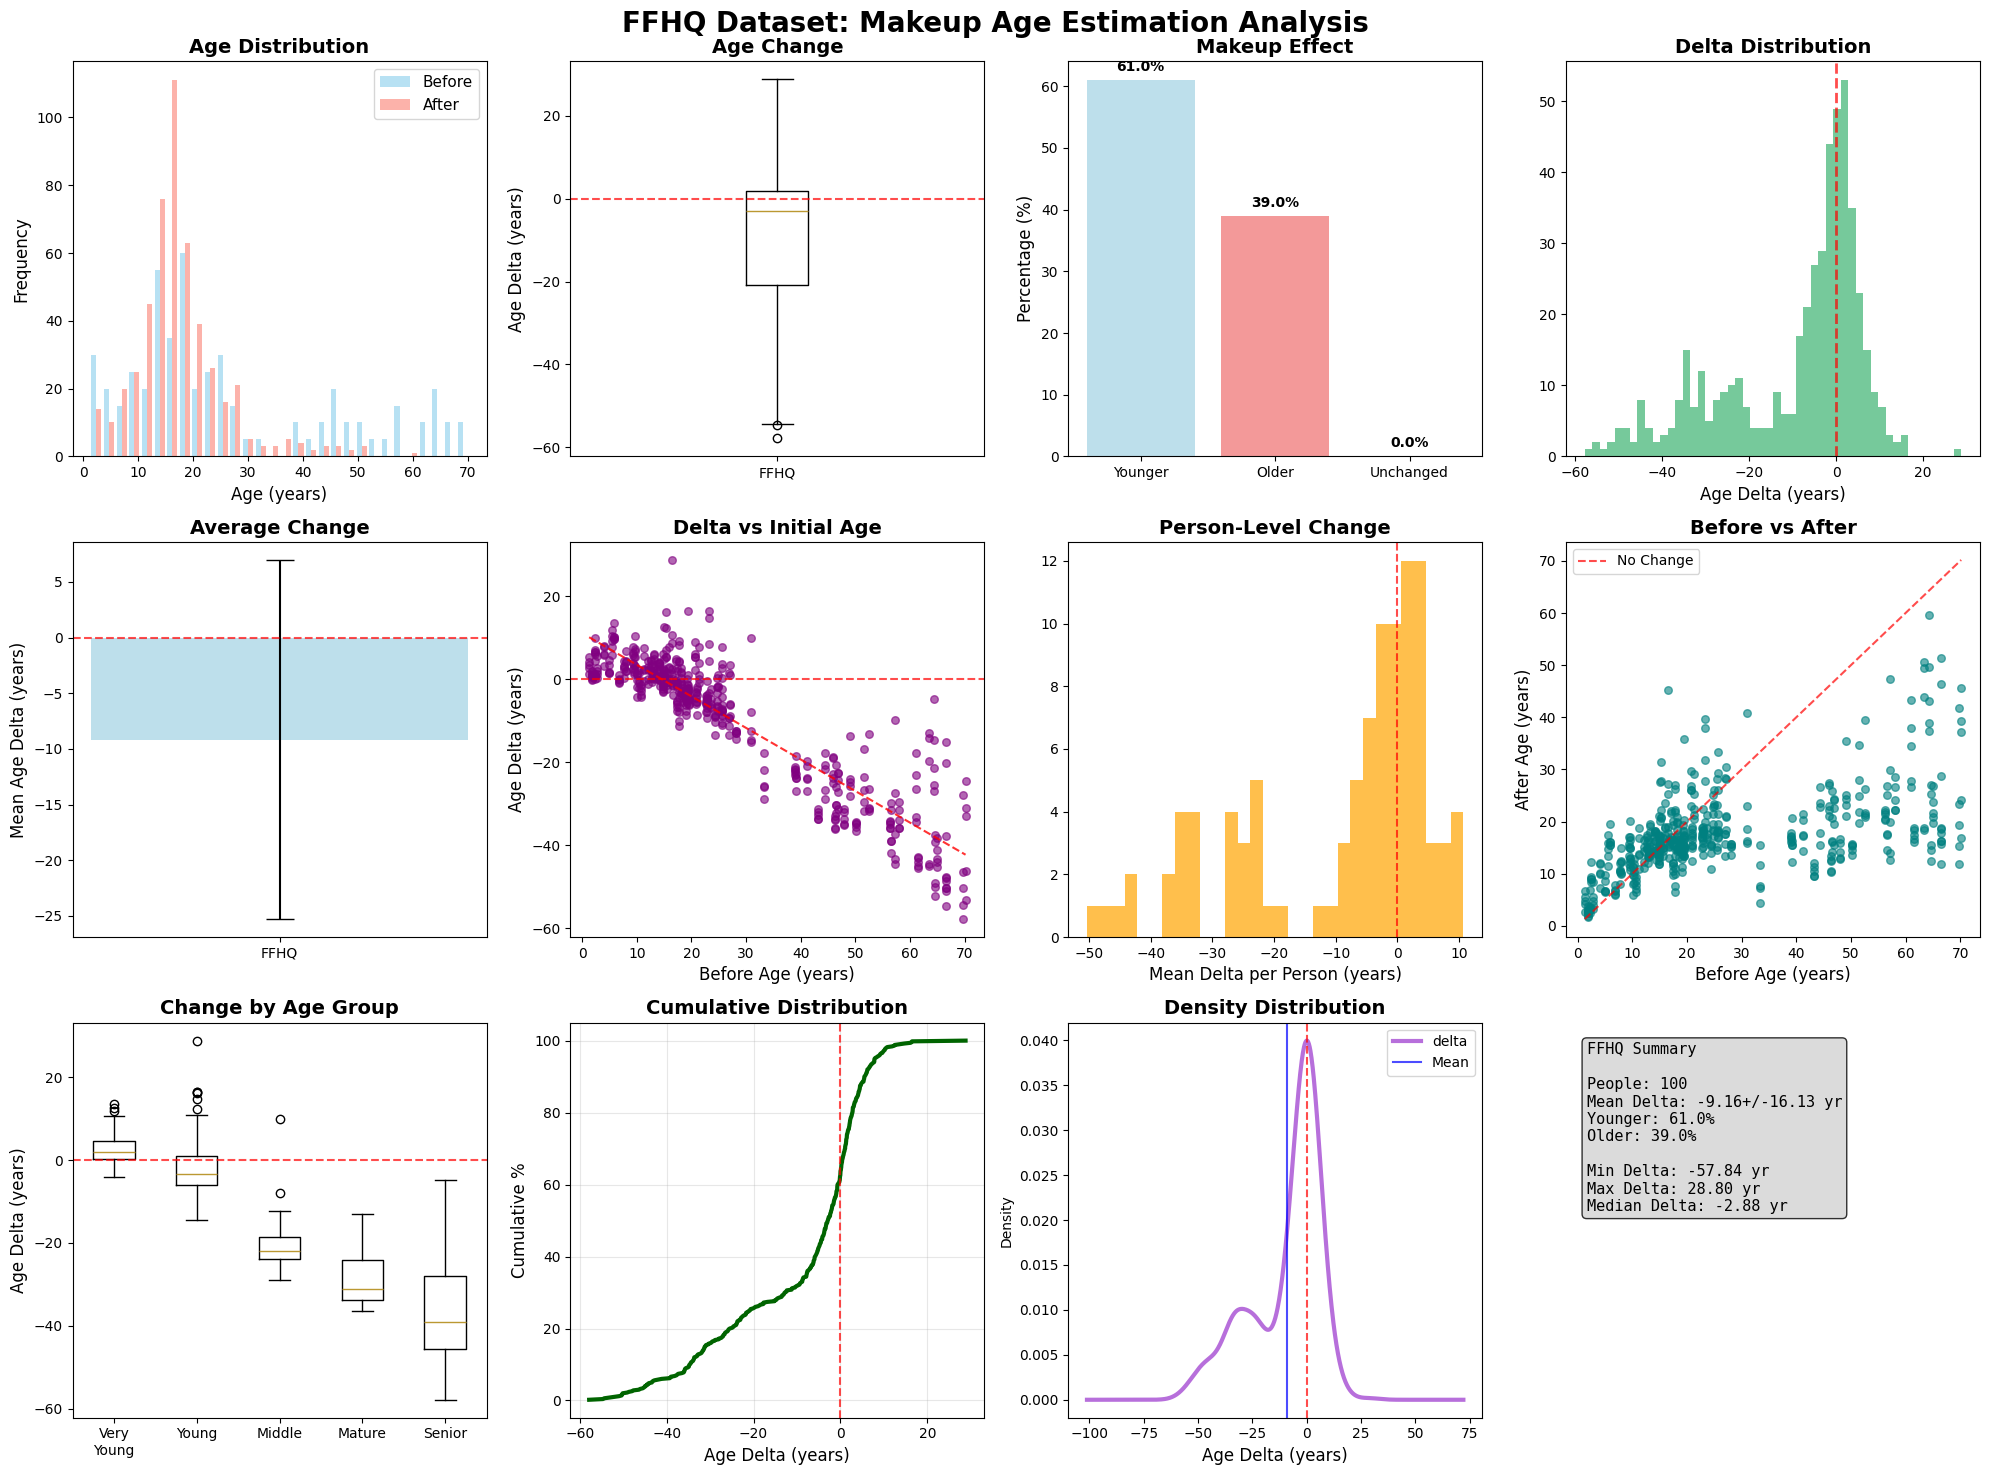

Saved: output_images\LADN_detailed_analysis.png


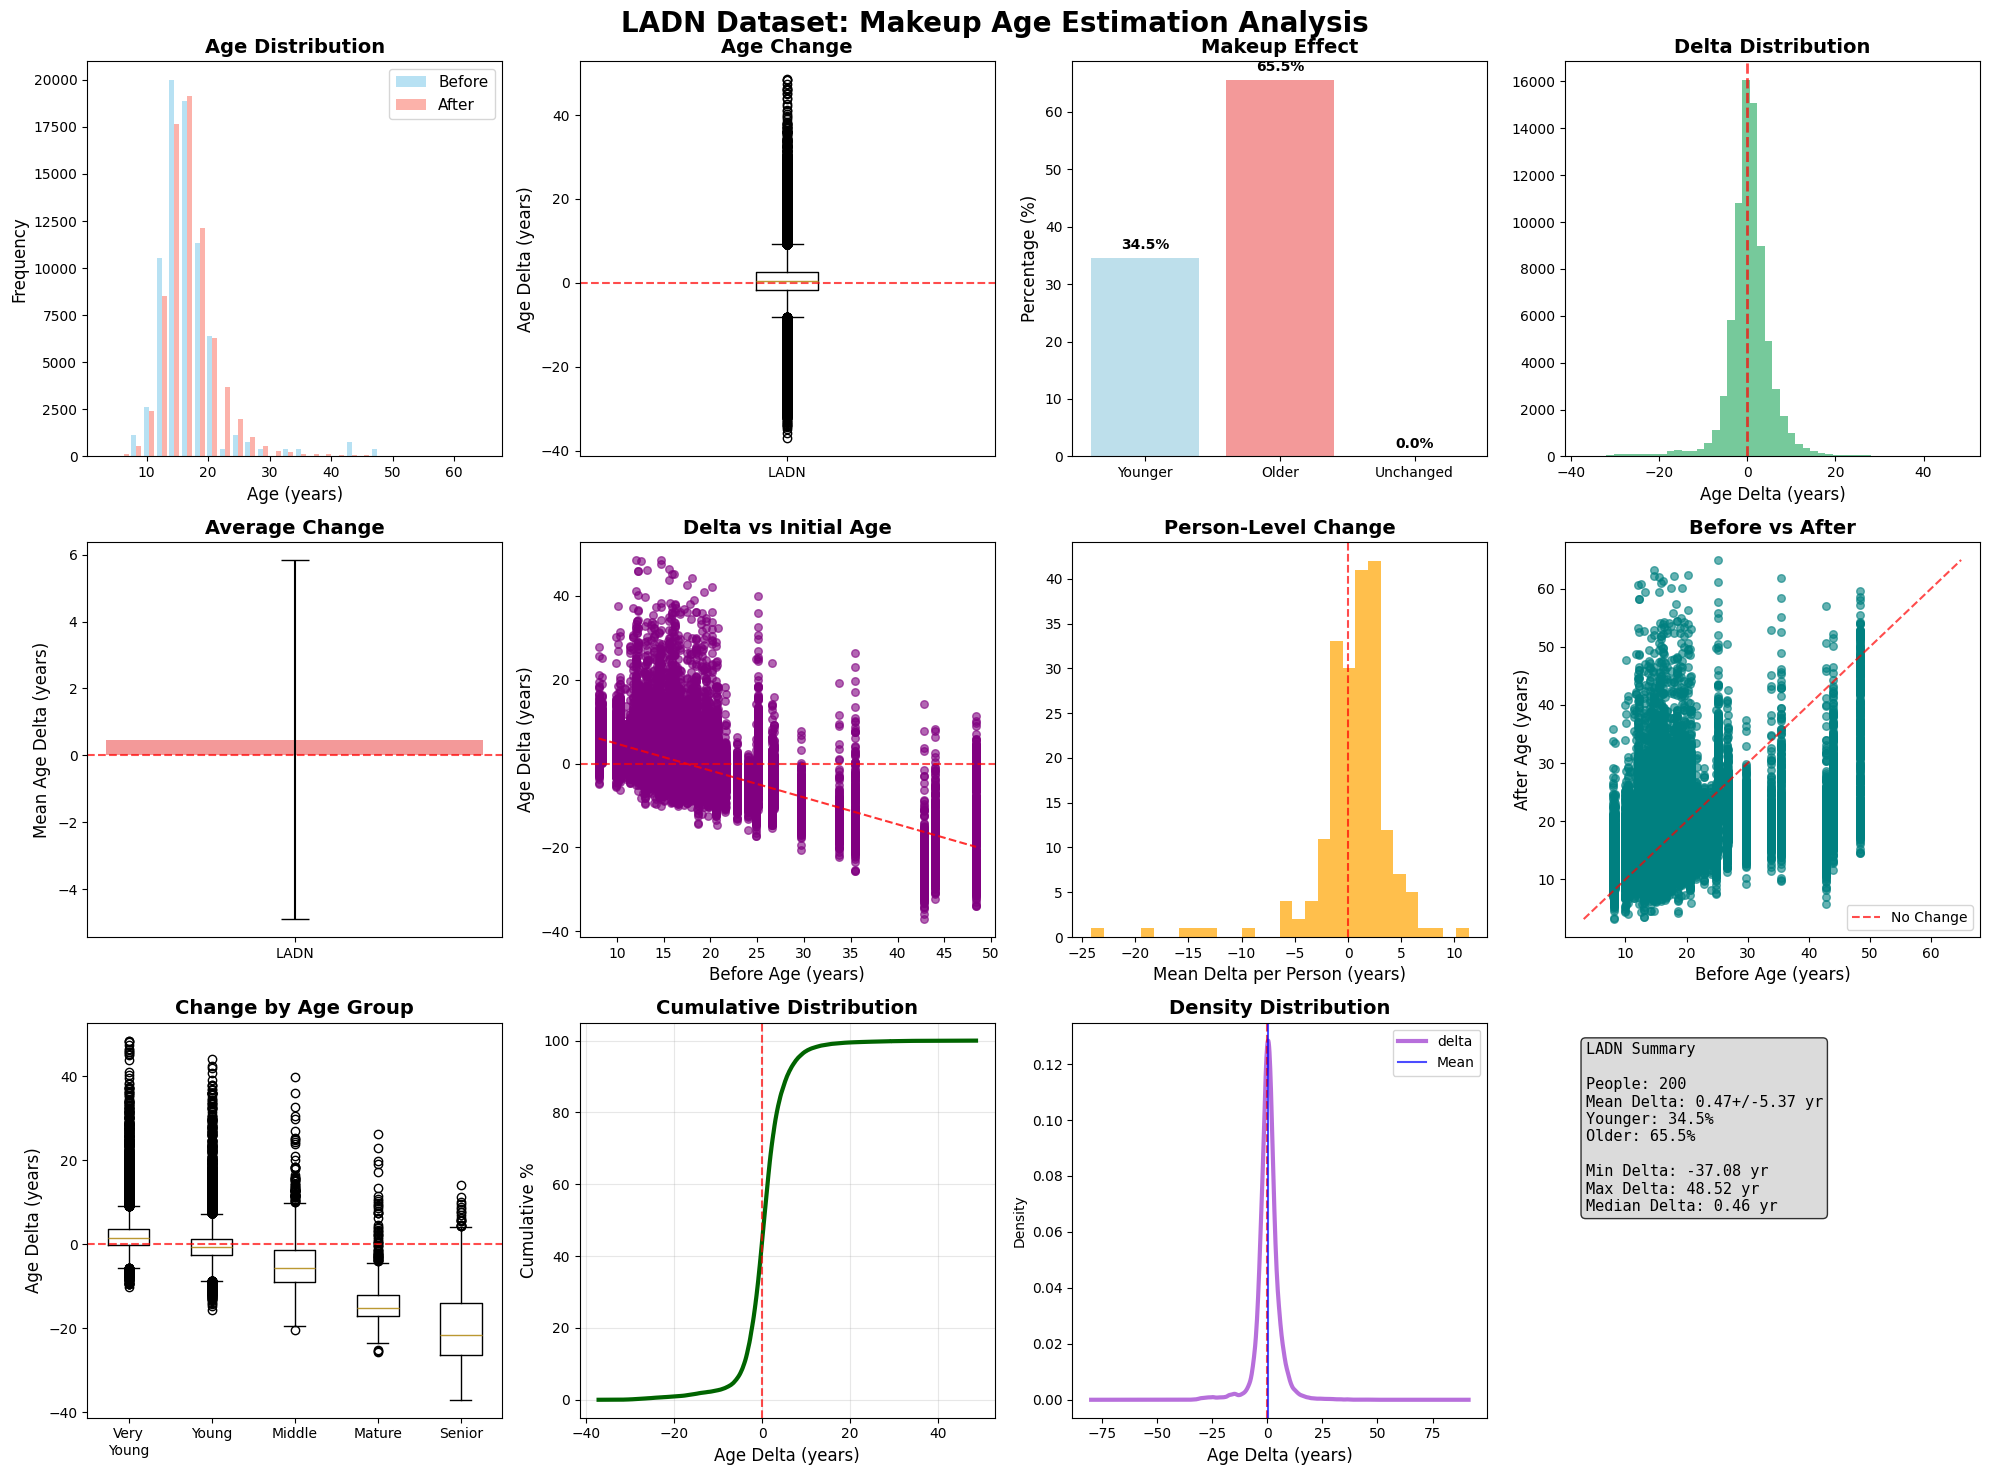

\n✅ Visualizations completed!
📁 Saved to: output_images/ folder


In [ ]:
# Generate comprehensive visualizations for both datasets
print("Creating visualizations...")
print()

results_files = [
    os.path.join("outputs", "ffhq_makeup_analysis_detailed.csv"),
    os.path.join("outputs", "blend_makeup_analysis_detailed.csv")
]
summary_files = [
    os.path.join("outputs", "ffhq_makeup_analysis_detailed_summary.csv"),
    os.path.join("outputs", "blend_makeup_analysis_detailed_summary.csv")
]

create_visualizations(results_files, summary_files, mode='detailed')

## Analysis Complete!

### Summary:
- **Datasets**: FFHQ (bare + 5 makeup variants), Blend (before + blend variants)
- **Analysis**: Age predictions, delta calculations, statistical metrics
- **Outputs**: CSV files in `outputs/`, visualizations in `output_images/`
- **Metrics**: mean_delta, std_delta, percentage younger/older, per-person tracking

### Generated Files:
- **Outputs folder**: `*_detailed.csv`, `*_summary.csv`
- **Output_images folder**: Comprehensive visualizations

### Key Functions:
- `comprehensive_makeup_analysis()` - Run analysis on datasets
- `create_visualizations()` - Generate all plots
- `load_blend_dataset()` / `load_ffhq_makeup_dataset()` - Dataset loaders

## Variance Analysis: Makeup vs Bare Faces

Visualization showing how makeup introduction increases variance in age estimations

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

def create_variance_comparison_visualization(results_files):
    """
    Create a comprehensive visualization showing how makeup increases variance in age estimations
    compared to bare faces.
    
    Args:
        results_files: List of paths to detailed results CSV files
    """
    # Set style for professional plots
    plt.style.use('default')
    sns.set_palette("Set2")
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # Load all datasets
    all_data = []
    dataset_names = []
    
    for results_file in results_files:
        if os.path.exists(results_file):
            df = pd.read_csv(results_file)
            dataset_name = os.path.basename(results_file).split('_')[0].upper()
            df['dataset'] = dataset_name
            all_data.append(df)
            dataset_names.append(dataset_name)
            print(f"Loaded {dataset_name}: {len(df)} predictions, {df['person_id'].nunique()} people")
    
    if not all_data:
        print("No data files found!")
        return
    
    # Combine all data
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # ==========================
    # 1. MAIN VISUALIZATION: Variance Comparison (Top - Large)
    # ==========================
    ax_main = fig.add_subplot(gs[0, :])
    
    # Calculate variance for bare vs makeup ages per person
    variance_data = []
    for dataset_name in dataset_names:
        dataset_df = combined_df[combined_df['dataset'] == dataset_name]
        
        for person_id in dataset_df['person_id'].unique():
            person_data = dataset_df[dataset_df['person_id'] == person_id]
            
            # Bare face has 0 variance (single measurement)
            bare_age = person_data['before_age'].iloc[0]
            variance_data.append({
                'dataset': dataset_name,
                'person_id': person_id,
                'condition': 'Bare Face',
                'age': bare_age,
                'variance': 0.0  # Single measurement, no variance
            })
            
            # Makeup variants have variance
            makeup_ages = person_data['makeup_age'].values
            if len(makeup_ages) > 1:
                makeup_variance = np.var(makeup_ages)
            else:
                makeup_variance = 0.0
            
            for makeup_age in makeup_ages:
                variance_data.append({
                    'dataset': dataset_name,
                    'person_id': person_id,
                    'condition': 'With Makeup',
                    'age': makeup_age,
                    'variance': makeup_variance
                })
    
    variance_df = pd.DataFrame(variance_data)
    
    # Create violin plot with swarm overlay
    positions = [0, 1.5]
    bare_variances = variance_df[variance_df['condition'] == 'Bare Face']['variance'].values
    makeup_variances = variance_df[variance_df['condition'] == 'With Makeup'].groupby(
        variance_df[variance_df['condition'] == 'With Makeup']['person_id']
    )['variance'].first().values
    
    # Violin plots
    parts = ax_main.violinplot([bare_variances, makeup_variances], positions=positions,
                                showmeans=True, showmedians=True, widths=0.7)
    
    # Color the violin plots
    colors = ['#90EE90', '#FF6B6B']
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1.5)
    
    # Enhance the mean/median lines
    parts['cmeans'].set_color('darkblue')
    parts['cmeans'].set_linewidth(3)
    parts['cmedians'].set_color('darkred')
    parts['cmedians'].set_linewidth(2)
    parts['cmedians'].set_linestyle('--')
    
    # Add box plots for quartile info
    bp = ax_main.boxplot([bare_variances, makeup_variances], positions=positions,
                          widths=0.15, patch_artist=True,
                          boxprops=dict(facecolor='white', alpha=0.6),
                          medianprops=dict(color='red', linewidth=2),
                          whiskerprops=dict(linewidth=1.5),
                          capprops=dict(linewidth=1.5))
    
    # Statistical annotation
    bare_mean = np.mean(bare_variances)
    makeup_mean = np.mean(makeup_variances)
    variance_increase = ((makeup_mean - bare_mean) / (bare_mean + 0.001)) * 100  # Add small constant to avoid division by zero
    
    # Perform statistical test
    if makeup_mean > 0:
        _, p_value = stats.mannwhitneyu(bare_variances, makeup_variances, alternative='less')
        sig_marker = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    else:
        sig_marker = "ns"
        p_value = 1.0
    
    # Add connecting line and significance
    y_max = max(np.max(bare_variances), np.max(makeup_variances))
    line_height = y_max * 1.1
    ax_main.plot([0, 1.5], [line_height, line_height], 'k-', linewidth=2)
    ax_main.text(0.75, line_height * 1.05, f'{sig_marker}\np={p_value:.4f}', 
                ha='center', fontsize=12, fontweight='bold')
    
    # Labels and title
    ax_main.set_xticks(positions)
    ax_main.set_xticklabels(['Bare Face', 'With Makeup'], fontsize=14, fontweight='bold')
    ax_main.set_ylabel('Variance in Age Estimation (years²)', fontsize=14, fontweight='bold')
    ax_main.set_title('Impact of Makeup on Age Estimation Variance\n(Makeup Increases Prediction Uncertainty)', 
                     fontsize=16, fontweight='bold', pad=20)
    ax_main.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add text box with statistics
    stats_text = f'Bare Face:\n  Mean Variance: {bare_mean:.2f} yr²\n  Std: {np.std(bare_variances):.2f}\n\n'
    stats_text += f'With Makeup:\n  Mean Variance: {makeup_mean:.2f} yr²\n  Std: {np.std(makeup_variances):.2f}\n\n'
    stats_text += f'Increase: {variance_increase:.0f}%' if variance_increase < 999 else 'Increase: Infinite'
    
    ax_main.text(0.02, 0.98, stats_text, transform=ax_main.transAxes,
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.9, edgecolor='black', linewidth=2))
    
    # ==========================
    # 2. Standard Deviation Comparison
    # ==========================
    ax2 = fig.add_subplot(gs[1, 0])
    
    std_data = []
    for person_id in combined_df['person_id'].unique():
        person_data = combined_df[combined_df['person_id'] == person_id]
        bare_age = person_data['before_age'].iloc[0]
        makeup_ages = person_data['makeup_age'].values
        
        std_data.append({
            'Bare Face': 0.0,  # Single measurement
            'With Makeup': np.std(makeup_ages) if len(makeup_ages) > 1 else 0.0
        })
    
    std_df = pd.DataFrame(std_data)
    
    # Box plot for standard deviations
    bp2 = ax2.boxplot([std_df['Bare Face'], std_df['With Makeup']], 
                       labels=['Bare', 'Makeup'],
                       patch_artist=True,
                       notch=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2.5))
    
    ax2.set_ylabel('Standard Deviation (years)', fontsize=11, fontweight='bold')
    ax2.set_title('Prediction Consistency', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # Add mean markers
    ax2.scatter([1, 2], [std_df['Bare Face'].mean(), std_df['With Makeup'].mean()],
               color='darkblue', s=100, zorder=5, marker='D', label='Mean')
    ax2.legend()
    
    # ==========================
    # 3. Distribution of Age Deltas
    # ==========================
    ax3 = fig.add_subplot(gs[1, 1])
    
    # Calculate absolute deltas (how much predictions vary from bare face)
    abs_deltas = np.abs(combined_df['delta'].values)
    
    ax3.hist(abs_deltas, bins=30, color='coral', alpha=0.7, edgecolor='black')
    ax3.axvline(np.mean(abs_deltas), color='darkred', linestyle='--', linewidth=2.5, 
               label=f'Mean: {np.mean(abs_deltas):.2f} yr')
    ax3.axvline(np.median(abs_deltas), color='darkblue', linestyle='--', linewidth=2.5,
               label=f'Median: {np.median(abs_deltas):.2f} yr')
    
    ax3.set_xlabel('Absolute Age Delta (years)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax3.set_title('Distribution of Estimation Changes', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # ==========================
    # 4. Coefficient of Variation
    # ==========================
    ax4 = fig.add_subplot(gs[1, 2])
    
    cv_data = []
    for person_id in combined_df['person_id'].unique():
        person_data = combined_df[combined_df['person_id'] == person_id]
        bare_age = person_data['before_age'].iloc[0]
        makeup_ages = person_data['makeup_age'].values
        
        if bare_age > 0:
            bare_cv = 0.0  # Single measurement
            makeup_cv = (np.std(makeup_ages) / np.mean(makeup_ages) * 100) if len(makeup_ages) > 1 and np.mean(makeup_ages) > 0 else 0.0
            
            cv_data.append({
                'person_id': person_id,
                'Bare Face': bare_cv,
                'With Makeup': makeup_cv
            })
    
    cv_df = pd.DataFrame(cv_data)
    
    # Bar plot comparing average CV
    cv_means = [cv_df['Bare Face'].mean(), cv_df['With Makeup'].mean()]
    bars = ax4.bar(['Bare', 'Makeup'], cv_means, color=['lightgreen', 'salmon'], 
                   alpha=0.7, edgecolor='black', linewidth=2)
    
    # Add error bars
    cv_stds = [cv_df['Bare Face'].std(), cv_df['With Makeup'].std()]
    ax4.errorbar(['Bare', 'Makeup'], cv_means, yerr=cv_stds, fmt='none', 
                color='black', capsize=10, linewidth=2)
    
    # Add value labels on bars
    for bar, mean_val in zip(bars, cv_means):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean_val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax4.set_ylabel('Coefficient of Variation (%)', fontsize=11, fontweight='bold')
    ax4.set_title('Relative Variability', fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    
    # ==========================
    # 5. Range of Predictions per Person
    # ==========================
    ax5 = fig.add_subplot(gs[2, 0])
    
    range_data = []
    for person_id in combined_df['person_id'].unique():
        person_data = combined_df[combined_df['person_id'] == person_id]
        bare_age = person_data['before_age'].iloc[0]
        makeup_ages = person_data['makeup_age'].values
        
        bare_range = 0.0  # Single measurement
        makeup_range = np.max(makeup_ages) - np.min(makeup_ages) if len(makeup_ages) > 1 else 0.0
        
        range_data.append({
            'Bare': bare_range,
            'Makeup': makeup_range
        })
    
    range_df = pd.DataFrame(range_data)
    
    # Scatter plot
    ax5.scatter(range_df['Bare'], range_df['Makeup'], alpha=0.6, s=50, c='purple')
    
    # Add diagonal line
    max_range = max(range_df['Makeup'].max(), 1)
    ax5.plot([0, max_range], [0, max_range], 'r--', linewidth=2, alpha=0.5, label='Equal Range')
    
    ax5.set_xlabel('Bare Face Range (years)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Makeup Range (years)', fontsize=11, fontweight='bold')
    ax5.set_title('Prediction Range per Person', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    # ==========================
    # 6. Cumulative Distribution
    # ==========================
    ax6 = fig.add_subplot(gs[2, 1])
    
    sorted_makeup_std = np.sort(std_df['With Makeup'].values)
    cumulative = np.arange(1, len(sorted_makeup_std) + 1) / len(sorted_makeup_std) * 100
    
    ax6.plot(sorted_makeup_std, cumulative, linewidth=3, color='darkgreen')
    ax6.axhline(y=50, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Median')
    ax6.axhline(y=95, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='95th percentile')
    
    ax6.set_xlabel('Std Dev with Makeup (years)', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Cumulative Percentage (%)', fontsize=11, fontweight='bold')
    ax6.set_title('Cumulative Distribution of Variability', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(alpha=0.3)
    
    # ==========================
    # 7. Summary Statistics Table
    # ==========================
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('off')
    
    summary_text = "SUMMARY STATISTICS\n" + "="*35 + "\n\n"
    summary_text += f"Total People: {combined_df['person_id'].nunique()}\n"
    summary_text += f"Total Predictions: {len(combined_df)}\n"
    summary_text += f"Datasets: {', '.join(dataset_names)}\n\n"
    
    summary_text += "VARIANCE (years²):\n"
    summary_text += f"  Bare: {bare_mean:.3f} ± {np.std(bare_variances):.3f}\n"
    summary_text += f"  Makeup: {makeup_mean:.3f} ± {np.std(makeup_variances):.3f}\n"
    summary_text += f"  Increase: {variance_increase:.1f}%\n\n" if variance_increase < 999 else f"  Increase: Infinite\n\n"
    
    summary_text += "STD DEVIATION (years):\n"
    summary_text += f"  Bare: {std_df['Bare Face'].mean():.3f}\n"
    summary_text += f"  Makeup: {std_df['With Makeup'].mean():.3f}\n\n"
    
    summary_text += "STATISTICAL TEST:\n"
    summary_text += f"  p-value: {p_value:.4f}\n"
    summary_text += f"  Significance: {sig_marker}\n\n"
    
    summary_text += "INTERPRETATION:\n"
    if makeup_mean > bare_mean and p_value < 0.05:
        summary_text += "  Makeup SIGNIFICANTLY\n"
        summary_text += "  increases estimation\n"
        summary_text += "  variance (uncertainty)"
    else:
        summary_text += "  No significant\n"
        summary_text += "  difference detected"
    
    ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes,
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle="round,pad=0.8", facecolor="lightcyan", alpha=0.9, 
                     edgecolor='darkblue', linewidth=2))
    
    # Save figure
    output_path = os.path.join('output_images', 'variance_analysis_makeup_vs_bare.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n{'='*70}")
    print(f"Visualization saved: {output_path}")
    print(f"{'='*70}")
    
    plt.show()
    
    return variance_df, std_df, cv_df

print("Variance comparison visualization function created!")
print("Ready to analyze makeup-induced variance in age estimations")

Variance comparison visualization function created!
Ready to analyze makeup-induced variance in age estimations


Creating variance analysis visualization...
This shows how makeup increases uncertainty/variance in age predictions

Loaded FFHQ: 500 predictions, 100 people
Loaded BLEND: 75400 predictions, 200 people


C:\Users\Frank\AppData\Local\Temp\ipykernel_29108\475302875.py:174: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([std_df['Bare Face'], std_df['With Makeup']],



Visualization saved: output_images\variance_analysis_makeup_vs_bare.png


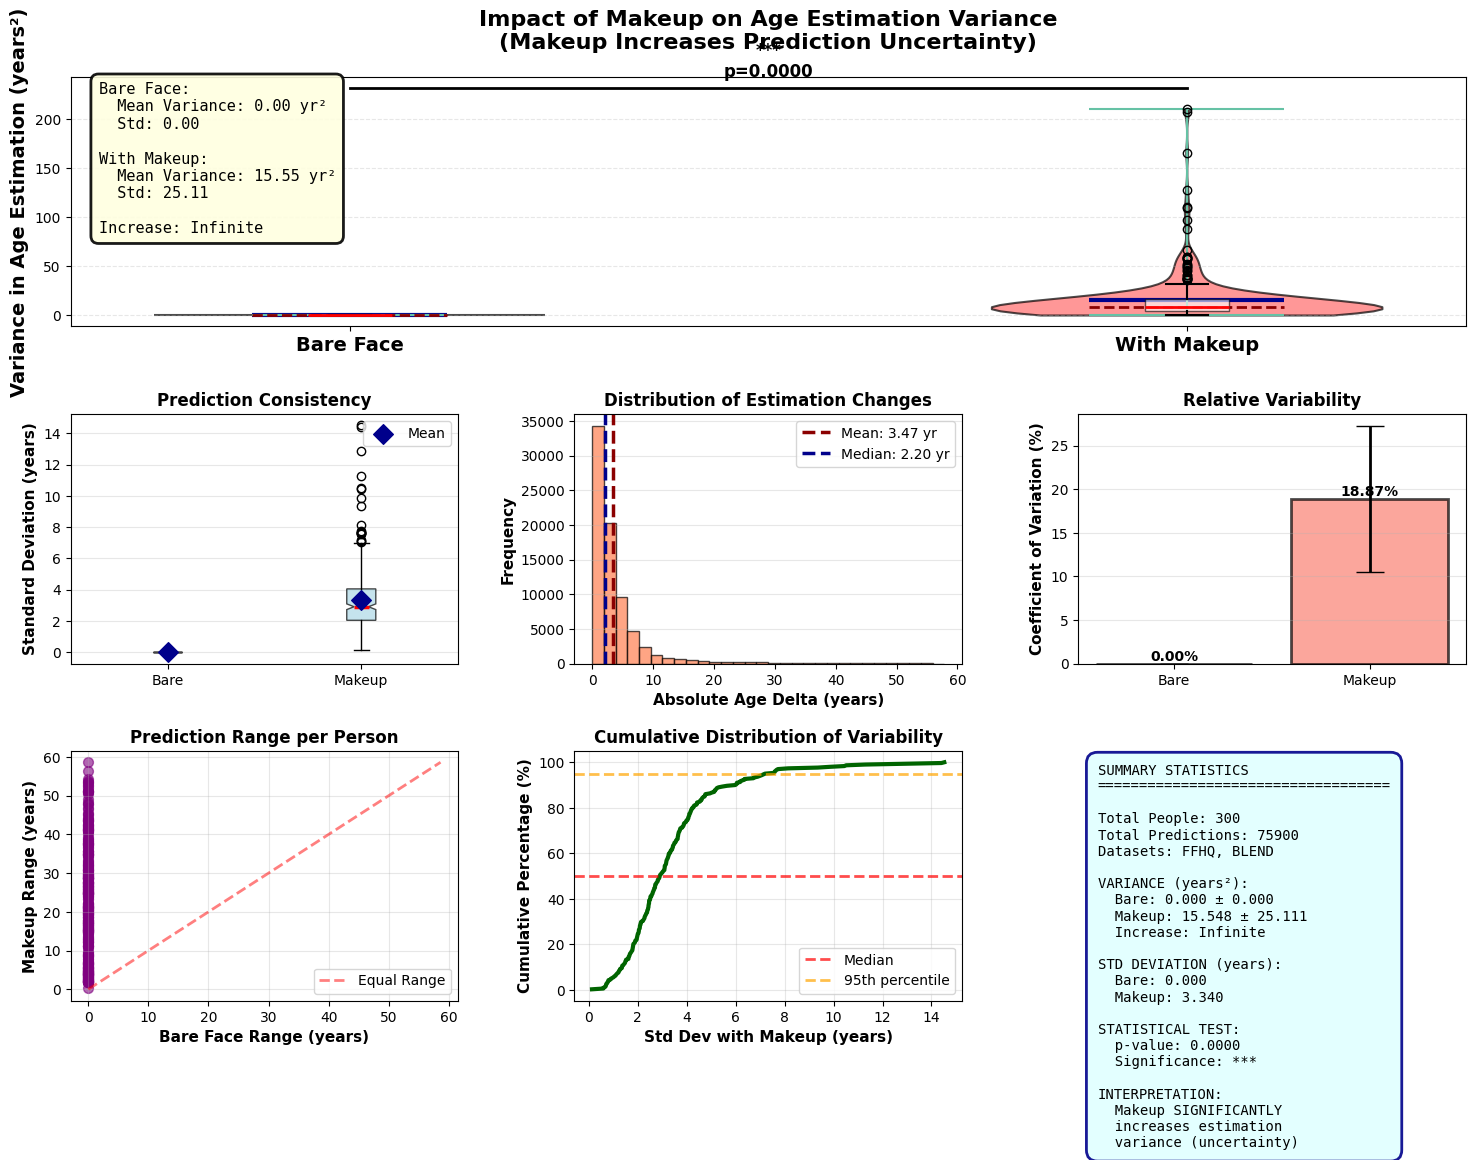


KEY FINDINGS:
1. Bare faces have ZERO variance (single measurement)
2. Makeup introduces variance in predictions:
   - Mean variance with makeup: 15.548 years²
   - Mean std dev with makeup: 3.340 years
3. This demonstrates that makeup makes age estimation LESS RELIABLE
4. Different makeup styles produce different age estimates for the same person


In [4]:
# Generate variance comparison visualization
print("Creating variance analysis visualization...")
print("This shows how makeup increases uncertainty/variance in age predictions")
print()

# Define the results files from previous analysis
results_files = [
    os.path.join("outputs", "ffhq_makeup_analysis_detailed.csv"),
    os.path.join("outputs", "blend_makeup_analysis_detailed.csv")
]

# Run the variance analysis
variance_df, std_df, cv_df = create_variance_comparison_visualization(results_files)

# Display key findings
print("\n" + "="*70)
print("KEY FINDINGS:")
print("="*70)
print(f"1. Bare faces have ZERO variance (single measurement)")
print(f"2. Makeup introduces variance in predictions:")
print(f"   - Mean variance with makeup: {variance_df[variance_df['condition']=='With Makeup'].groupby('person_id')['variance'].first().mean():.3f} years²")
print(f"   - Mean std dev with makeup: {std_df['With Makeup'].mean():.3f} years")
print(f"3. This demonstrates that makeup makes age estimation LESS RELIABLE")
print(f"4. Different makeup styles produce different age estimates for the same person")
print("="*70)

✓ Saved: output_images\variance_distribution_comparison.png


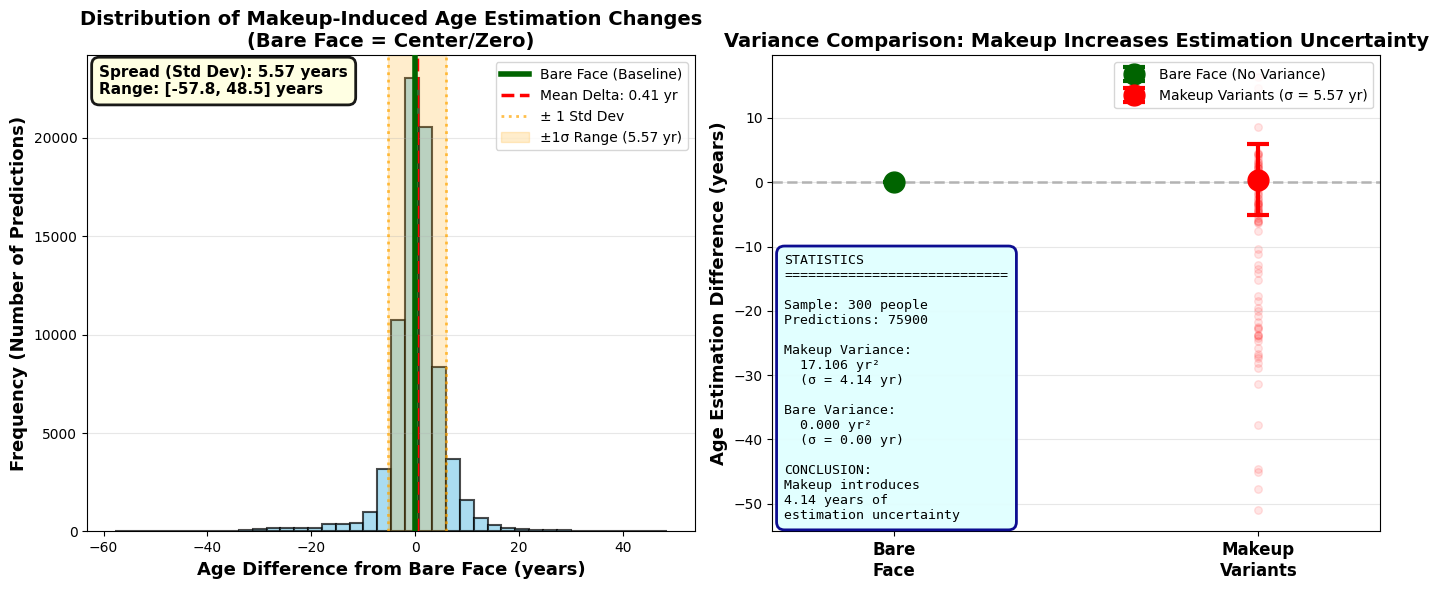


VARIANCE ANALYSIS SUMMARY
Sample Size:              300 people (75900 predictions)

Bare Face (Baseline):     0.000 years² variance (σ = 0.00 yr)
Makeup Variants:          17.106 years² variance (σ = 4.14 yr)

Mean Age Shift:           0.41 years
Spread (Std Dev):         5.57 years
Range:                    [-57.84, 48.52] years

CONCLUSION:................... Makeup introduces 4.14 years of uncertainty
.............................. in age estimations, with predictions
.............................. varying by ±5.57 years around the mean.


In [6]:
# Variance Visualization: Bare Face (Center) vs Makeup Variants (Distribution)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import stats

# Load the data
results_files = [
    os.path.join("outputs", "ffhq_makeup_analysis_detailed.csv"),
    os.path.join("outputs", "blend_makeup_analysis_detailed.csv")
]

all_data = []
for results_file in results_files:
    if os.path.exists(results_file):
        df = pd.read_csv(results_file)
        all_data.append(df)

if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Calculate the distribution of age deltas (difference from bare face)
    all_deltas = combined_df['delta'].values  # makeup_age - before_age
    
    # Calculate statistics
    n_people = combined_df['person_id'].nunique()
    n_predictions = len(all_deltas)
    mean_delta = np.mean(all_deltas)
    std_delta = np.std(all_deltas)
    
    # Calculate variance in makeup predictions per person
    makeup_variances = []
    for person_id in combined_df['person_id'].unique():
        person_data = combined_df[combined_df['person_id'] == person_id]
        makeup_ages = person_data['makeup_age'].values
        if len(makeup_ages) > 1:
            makeup_var = np.var(makeup_ages, ddof=1)
            makeup_variances.append(makeup_var)
    
    avg_makeup_variance = np.mean(makeup_variances)
    avg_makeup_std = np.sqrt(avg_makeup_variance)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(14, 6))
    
    # ========== LEFT PLOT: Distribution with Bare Face as Center ==========
    ax1 = plt.subplot(1, 2, 1)
    
    # Create histogram of deltas
    counts, bins, patches = ax1.hist(all_deltas, bins=40, color='skyblue', alpha=0.7, 
                                     edgecolor='black', linewidth=1.5)
    
    # Mark the bare face (delta = 0) as center
    ax1.axvline(x=0, color='darkgreen', linestyle='-', linewidth=4, 
               label='Bare Face (Baseline)', zorder=5)
    
    # Add mean and std lines
    ax1.axvline(x=mean_delta, color='red', linestyle='--', linewidth=2.5, 
               label=f'Mean Delta: {mean_delta:.2f} yr', zorder=4)
    ax1.axvline(x=mean_delta - std_delta, color='orange', linestyle=':', linewidth=2, 
               label=f'± 1 Std Dev', alpha=0.7, zorder=3)
    ax1.axvline(x=mean_delta + std_delta, color='orange', linestyle=':', linewidth=2, 
               alpha=0.7, zorder=3)
    
    # Fill the area within 1 std deviation
    ax1.axvspan(mean_delta - std_delta, mean_delta + std_delta, 
               alpha=0.2, color='orange', label=f'±1σ Range ({std_delta:.2f} yr)')
    
    ax1.set_xlabel('Age Difference from Bare Face (years)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Frequency (Number of Predictions)', fontsize=13, fontweight='bold')
    ax1.set_title('Distribution of Makeup-Induced Age Estimation Changes\n(Bare Face = Center/Zero)', 
                 fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add annotation showing the spread
    spread_text = f'Spread (Std Dev): {std_delta:.2f} years\n'
    spread_text += f'Range: [{all_deltas.min():.1f}, {all_deltas.max():.1f}] years'
    ax1.text(0.02, 0.98, spread_text, transform=ax1.transAxes,
            fontsize=11, verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", 
                     alpha=0.9, edgecolor='black', linewidth=2))
    
    # ========== RIGHT PLOT: Error Bars Showing Variance ==========
    ax2 = plt.subplot(1, 2, 2)
    
    # Create a simple comparison visualization
    positions = [1]
    
    # Plot bare face as a point with no error (single measurement)
    ax2.errorbar([0.7], [0], yerr=0, fmt='o', markersize=15, color='darkgreen', 
                 capsize=8, capthick=3, linewidth=3, 
                 label='Bare Face (No Variance)', zorder=5)
    
    # Plot makeup as a point with error bars showing the variance
    ax2.errorbar([1.3], [mean_delta], yerr=std_delta, fmt='o', markersize=15, 
                 color='red', capsize=8, capthick=3, linewidth=3, 
                 label=f'Makeup Variants (σ = {std_delta:.2f} yr)', zorder=5)
    
    # Add a visual representation of the spread
    ax2.scatter([1.3]*len(all_deltas[:100]), all_deltas[:100], 
               alpha=0.1, s=30, color='red', zorder=1)
    
    # Styling
    ax2.axhline(y=0, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    ax2.set_xlim(0.5, 1.5)
    ax2.set_xticks([0.7, 1.3])
    ax2.set_xticklabels(['Bare\nFace', 'Makeup\nVariants'], fontsize=12, fontweight='bold')
    ax2.set_ylabel('Age Estimation Difference (years)', fontsize=13, fontweight='bold')
    ax2.set_title('Variance Comparison: Makeup Increases Estimation Uncertainty', 
                 fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    
    # Add statistics box
    stats_text = f'STATISTICS\n{"="*28}\n\n'
    stats_text += f'Sample: {n_people} people\n'
    stats_text += f'Predictions: {n_predictions}\n\n'
    stats_text += f'Makeup Variance:\n'
    stats_text += f'  {avg_makeup_variance:.3f} yr²\n'
    stats_text += f'  (σ = {avg_makeup_std:.2f} yr)\n\n'
    stats_text += f'Bare Variance:\n'
    stats_text += f'  0.000 yr²\n'
    stats_text += f'  (σ = 0.00 yr)\n\n'
    stats_text += f'CONCLUSION:\n'
    stats_text += f'Makeup introduces\n'
    stats_text += f'{avg_makeup_std:.2f} years of\n'
    stats_text += f'estimation uncertainty'
    
    ax2.text(0.02, 0.02, stats_text, transform=ax2.transAxes,
            fontsize=9.5, verticalalignment='bottom',
            fontfamily='monospace',
            bbox=dict(boxstyle="round,pad=0.6", facecolor="lightcyan", 
                     alpha=0.95, edgecolor='darkblue', linewidth=2))
    
    plt.tight_layout()
    
    # Save
    output_path = os.path.join('output_images', 'variance_distribution_comparison.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ Saved: {output_path}")
    
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("VARIANCE ANALYSIS SUMMARY")
    print("="*70)
    print(f"Sample Size:              {n_people} people ({n_predictions} predictions)")
    print(f"\nBare Face (Baseline):     0.000 years² variance (σ = 0.00 yr)")
    print(f"Makeup Variants:          {avg_makeup_variance:.3f} years² variance (σ = {avg_makeup_std:.2f} yr)")
    print(f"\nMean Age Shift:           {mean_delta:.2f} years")
    print(f"Spread (Std Dev):         {std_delta:.2f} years")
    print(f"Range:                    [{all_deltas.min():.2f}, {all_deltas.max():.2f}] years")
    print(f"\n{'CONCLUSION:':.<30} Makeup introduces {avg_makeup_std:.2f} years of uncertainty")
    print(f"{'':.<30} in age estimations, with predictions")
    print(f"{'':.<30} varying by ±{std_delta:.2f} years around the mean.")
    print("="*70)
else:
    print("No data files found in outputs/ directory")